## begin by importing all necessary packages

In [1]:

import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import scipy
from scipy.signal import resample_poly
import re
import json
import glob
from IPython.display import display
import h5py
import shutil
import tdt
from collections import defaultdict
from pathlib import Path
from re import search
from scipy.sparse import csc_matrix, eye, diags
from scipy.sparse.linalg import spsolve
%load_ext autoreload
%autoreload 2

# this is the list from Photometry data preprocessing.ipynb, from the Simpson et al. Neuron primer

from scipy.signal import find_peaks, peak_prominences
from scipy.signal import medfilt, butter, filtfilt
from scipy.stats import linregress
from scipy.optimize import curve_fit, minimize
from scipy import stats

#set default plot properties (this also from Simpson et al., 2024)
plt.rcParams['figure.figsize'] = [10, 8] # Make default figure size larger.
plt.rcParams['axes.xmargin'] = 0          # Make default margin on x axis zero.
plt.rcParams['axes.labelsize'] = 12     #Set default axes label size 
plt.rcParams['axes.titlesize']=15
plt.rcParams['axes.titleweight']='heavy'
plt.rcParams['ytick.labelsize']= 10
plt.rcParams['xtick.labelsize']= 10
plt.rcParams['legend.fontsize']=12
plt.rcParams['legend.markerscale']=2
plt.style.use('dark_background')
%matplotlib inline
    




## function used to extract and organize TDT data into tidy file structure

In [ ]:
# this is the function adapted from Adam Gordon-Fennell, which extracts information from the raw TDT files and organizes it into new feather files

#sys.path.append('./functions')   

from fp_func_acw import tidy_tdt_extract_and_tidy


# suggested format
#  - windows: r'C:\...\final_folder'
#  - mac: '/Users/.../final_folder/'

dir_raw = r"D:\ACW\photometry\pilot_recordings_raw\2025_new_prog_tests\testing_fipho_10.07.25\reinstatement_test-250930-180650"
dir_extracted = r"D:\ACW\photometry\pilot_recordings_extracted\2025_new_prog_tests\reinstatement"


tidy_tdt_extract_and_tidy(dir_raw, dir_extracted)


# ----------------------------------------------------------------------------------------------------------------------------


## function used to extract and organize Doric data into tidy file structure

In [3]:
# this function extracts specified datasets from the raw doric files


from fp_func_acw import doric_fipho_data_extraction


# suggested format
#  - windows: r'C:\...\final_folder'
#  - mac: '/Users/.../final_folder/'

dir_raw = r"D:\ACW\photometry\cohort_5_101325\raw\CR\coh5a"
dir_extracted = r"D:\ACW\photometry\cohort_5_101325\extracted\CR\coh5a"


doric_fipho_data_extraction(
    dir_raw=dir_raw,
    dir_extracted=dir_extracted
)


# ----------------------------------------------------------------------------------------------------------------------------


📁 Extracting from: D:\ACW\photometry\cohort_5_101325\raw\CR\coh5a
📤 Saving to: D:\ACW\photometry\cohort_5_101325\extracted\CR\coh5a

🔍 Processing ACW_coh5a_111325_0001.doric ...
✅ Saved: D:\ACW\photometry\cohort_5_101325\extracted\CR\coh5a\ACW_coh5a_111325_0001_streams_data.feather
✅ Saved: D:\ACW\photometry\cohort_5_101325\extracted\CR\coh5a\ACW_coh5a_111325_0001_streams_info.feather
✅ Saved: D:\ACW\photometry\cohort_5_101325\extracted\CR\coh5a\ACW_coh5a_111325_0001_epocs_data.feather

🔍 Processing ACW_coh5a_112025_0001.doric ...
✅ Saved: D:\ACW\photometry\cohort_5_101325\extracted\CR\coh5a\ACW_coh5a_112025_0001_streams_data.feather
✅ Saved: D:\ACW\photometry\cohort_5_101325\extracted\CR\coh5a\ACW_coh5a_112025_0001_streams_info.feather
✅ Saved: D:\ACW\photometry\cohort_5_101325\extracted\CR\coh5a\ACW_coh5a_112025_0001_epocs_data.feather

🔍 Processing ACW_coh5a_112025_0002.doric ...
✅ Saved: D:\ACW\photometry\cohort_5_101325\extracted\CR\coh5a\ACW_coh5a_112025_0002_streams_data.feathe

## choose the animals of interest

In [2]:

# list of all detected recording sessions corresponding to a particular animal or group animals

#_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-

# define the sub-cohort

subcoh = r"D:\ACW\photometry\cohort_5_101325\extracted\CR\coh5b\processed_sessions"


#_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-


#_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-



# define the IDs for the individual animals


BOX2_rat = 'ACW_coh5_IT_f3' 
BOX3_rat = 'ACW_coh5_IT_m4'
BOX4_rat = 'ACW_coh5_IT_'
BOX5_rat = 'ACW_coh5_IT_'



subcoh_rats = {
    'BOX2_rat': str(BOX2_rat),
    'BOX3_rat': str(BOX3_rat),
    'BOX4_rat': str(BOX4_rat),
    'BOX5_rat': str(BOX5_rat)
}



#_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-

# list of the recording sessions for this sub-cohort

files = os.listdir(subcoh)

# list comprehension steps
# Exclude any file that begins with "processed_"
files = [x for x in files if not x.startswith("processed_")]
files = [x for x in files if not x.startswith("multiday_processed_")]

# set comprehension steps to isolate unique blocknames
# trim file names to blocknames
files = {x.replace('_streams_info.feather','') for x in files}
files = {x.replace('_streams_data.feather','') for x in files}
files = {x.replace('_epocs_info.feather','')   for x in files}
files = {x.replace('_epocs_data.feather','')   for x in files}
files = {x.replace('_info.feather','')         for x in files}
files = {x.replace('_streams_preproc_downsamp.feather','')         for x in files}
files = {x.replace('_streams_preproc.feather','')         for x in files}
files = {x.replace('_GCaMP_465_dFF_epocs.feather','')         for x in files}
files = {x.replace('_GCaMP_465_epocs.feather','')         for x in files}
files = {x.replace('_epoc_ts_and_indices.feather','')         for x in files}

files = {x.replace(f'_{BOX2_rat}','')         for x in files}
files = {x.replace(f'_{BOX3_rat}','')         for x in files}
files = {x.replace(f'_{BOX4_rat}','')         for x in files}
files = {x.replace(f'_{BOX5_rat}','')         for x in files}


print(f'these are the {len(files)} session IDs for rats in sub-cohort: {subcoh}')
print(files)

print()

print(f'these are the rats in this sub-cohort:')
display(subcoh_rats)




these are the 4 session IDs for rats in sub-cohort: D:\ACW\photometry\cohort_5_101325\extracted\CR\coh5b\processed_sessions
{'ACW_coh5b_111525_0001', 'ACW_coh5b_112125_0001', 'ACW_coh5b_112225_0001', 'ACW_coh5b_111425_0001'}

these are the rats in this sub-cohort:


{'BOX2_rat': 'ACW_coh5_IT_f3',
 'BOX3_rat': 'ACW_coh5_IT_m4',
 'BOX4_rat': 'ACW_coh5_IT_',
 'BOX5_rat': 'ACW_coh5_IT_'}

## TDT recordings: choose the session ID and load stream feather files

In [ ]:

#_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-


session_id = r'/ACW_coh5_IT_f1-251007-184320'

#session_id = f"/{list(files)[0]}"   # this way, don't need to copy the name of the session ID each time.
print(session_id)

#_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-


streams_data = pd.read_feather(os.path.join(subcoh + session_id + '_streams_data.feather'))
streams_info = pd.read_feather(os.path.join(subcoh + session_id + '_streams_info.feather'))


# for one animal
'''
streams_info.rename(index={0: 'isosbestic'}, inplace=True)
streams_info.rename(index={1: 'GCaMP'}, inplace=True)

'''
# for four animals

streams_info.rename(index={0: f'isosbestic_{BOX2_rat}'}, inplace=True)
streams_info.rename(index={2: f'isosbestic_{BOX3_rat}'}, inplace=True)
streams_info.rename(index={4: f'isosbestic_{BOX4_rat}'}, inplace=True)
streams_info.rename(index={6: f'isosbestic_{BOX5_rat}'}, inplace=True)

streams_info.rename(index={1: f'GCaMP_{BOX2_rat}'}, inplace=True)
streams_info.rename(index={3: f'GCaMP_{BOX3_rat}'}, inplace=True)
streams_info.rename(index={5: f'GCaMP_{BOX4_rat}'}, inplace=True)
streams_info.rename(index={7: f'GCaMP_{BOX5_rat}'}, inplace=True)


# for three animals
'''
streams_info.rename(index={0: f'isosbestic_{BOX2_rat}'}, inplace=True)
streams_info.rename(index={2: f'isosbestic_{BOX4_rat}'}, inplace=True)
streams_info.rename(index={4: f'isosbestic_{BOX5_rat}'}, inplace=True)

streams_info.rename(index={1: f'GCaMP_{BOX2_rat}'}, inplace=True)
streams_info.rename(index={3: f'GCaMP_{BOX4_rat}'}, inplace=True)
streams_info.rename(index={5: f'GCaMP_{BOX5_rat}'}, inplace=True)
'''

streams_info
#streams_data
#display(epoc_info)

## Doric recordings: choose the session ID and load feather files

In [3]:
# select and load the specific recording of interest

#_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-


session_id = r'/ACW_coh5b_111425_0001'



#session_id = f"/{list(files)[0]}"   # this way, don't need to copy the name of the session ID each time.
print('session_id:\n')
print(session_id)

#_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-


streams_data = pd.read_feather(os.path.join(subcoh + session_id + '_streams_data.feather'))
streams_info = pd.read_feather(os.path.join(subcoh + session_id + '_streams_info.feather'))

print('streams_info:\n')
display(streams_info)
print('streams_data:\n')
display(streams_data)

epoc_data = pd.read_feather(os.path.join(subcoh + session_id + '_epocs_data.feather'))
print('epoc_data:\n')
display(epoc_data)


# ---------------------------
# Move processed files
# ---------------------------

# Clean session_id (remove leading slashes)
session_id = session_id.lstrip('/\\').strip()

# Define subfolder to store processed files
processed_folder = os.path.join(subcoh, "processed_sessions")
print('processed_folder:\n')
print(processed_folder)

# Create folder if it doesn't exist
os.makedirs(processed_folder, exist_ok=True)

# List of files for this session
session_files = [
    f"{session_id}_streams_data.feather",
    f"{session_id}_streams_info.feather",
    f"{session_id}_epocs_data.feather",    # optional, only if it exists
    f"{session_id}_epocs_info.feather"     # optional
]

for fname in session_files:
    src_path = os.path.join(subcoh, fname)
    if os.path.exists(src_path):
        dst_path = os.path.join(processed_folder, fname)
        shutil.move(src_path, dst_path)  # shutil is standard python tool for file management
        print(f"Moved {fname} → {processed_folder}")
    else:
        print(f"File not found, skipping: {fname}")




session_id:

/ACW_coh5b_111425_0001
streams_info:



,blockname,nickname,channel_raw,channel_name,fs,device_start_time,device_stop_time
0,ACW_coh5b_111425_0001,ACW_coh5_IT_f3,Headstage01LockIn01,Headstage01_470nm,100,09:44:21.916,10:52:11.711
1,ACW_coh5b_111425_0001,ACW_coh5_IT_f3,Headstage01LockIn02,Headstage01_415nm,100,09:44:21.916,10:52:11.711
2,ACW_coh5b_111425_0001,ACW_coh5_IT_m4,Headstage02LockIn01,Headstage02_470nm,100,09:44:21.916,10:52:11.711
3,ACW_coh5b_111425_0001,ACW_coh5_IT_m4,Headstage02LockIn02,Headstage02_415nm,100,09:44:21.916,10:52:11.711


streams_data:



,blockname,channel_raw,channel_name,nickname,time,raw_au
0,ACW_coh5b_111425_0001,Headstage01LockIn01,Headstage01_470nm,ACW_coh5_IT_f3,0.265416,0.028085
1,ACW_coh5b_111425_0001,Headstage01LockIn01,Headstage01_470nm,ACW_coh5_IT_f3,0.275416,0.028084
2,ACW_coh5b_111425_0001,Headstage01LockIn01,Headstage01_470nm,ACW_coh5_IT_f3,0.285416,0.028052
3,ACW_coh5b_111425_0001,Headstage01LockIn01,Headstage01_470nm,ACW_coh5_IT_f3,0.295416,0.027966
4,ACW_coh5b_111425_0001,Headstage01LockIn01,Headstage01_470nm,ACW_coh5_IT_f3,0.305416,0.027864
...,...,...,...,...,...,...
1623659,ACW_coh5b_111425_0001,Headstage02LockIn02,Headstage02_415nm,ACW_coh5_IT_m4,4069.657469,0.158049
1623660,ACW_coh5b_111425_0001,Headstage02LockIn02,Headstage02_415nm,ACW_coh5_IT_m4,4069.667469,0.158053
1623661,ACW_coh5b_111425_0001,Headstage02LockIn02,Headstage02_415nm,ACW_coh5_IT_m4,4069.677469,0.157921
1623662,ACW_coh5b_111425_0001,Headstage02LockIn02,Headstage02_415nm,ACW_coh5_IT_m4,4069.687469,0.157700


epoc_data:



,blockname,source_path,input code,onset
0,ACW_coh5b_111425_0001,Series0001/DigitalIO/DIO09,D09 Raw_DrugAvail_box2,395.313
1,ACW_coh5b_111425_0001,Series0001/DigitalIO/DIO10,D10 Raw_ActiveLever_box2,510.397
2,ACW_coh5b_111425_0001,Series0001/DigitalIO/DIO10,D10 Raw_ActiveLever_box2,516.998
3,ACW_coh5b_111425_0001,Series0001/DigitalIO/DIO10,D10 Raw_ActiveLever_box2,596.501
4,ACW_coh5b_111425_0001,Series0001/DigitalIO/DIO10,D10 Raw_ActiveLever_box2,597.951
...,...,...,...,...
135,ACW_coh5b_111425_0001,Series0001/DigitalIO/DIO14,D14 Raw_ActiveLever_box3,3629.416
136,ACW_coh5b_111425_0001,Series0001/DigitalIO/DIO15,D15 Raw_InactiveLever_box3,670.674
137,ACW_coh5b_111425_0001,Series0001/DigitalIO/DIO15,D15 Raw_InactiveLever_box3,3009.240
138,ACW_coh5b_111425_0001,Series0001/DigitalIO/DIO15,D15 Raw_InactiveLever_box3,3014.121


processed_folder:

D:\ACW\photometry\cohort_5_101325\extracted\CR\coh5b\processed_sessions\processed_sessions
Moved ACW_coh5b_111425_0001_streams_data.feather → D:\ACW\photometry\cohort_5_101325\extracted\CR\coh5b\processed_sessions\processed_sessions
Moved ACW_coh5b_111425_0001_streams_info.feather → D:\ACW\photometry\cohort_5_101325\extracted\CR\coh5b\processed_sessions\processed_sessions
Moved ACW_coh5b_111425_0001_epocs_data.feather → D:\ACW\photometry\cohort_5_101325\extracted\CR\coh5b\processed_sessions\processed_sessions
File not found, skipping: ACW_coh5b_111425_0001_epocs_info.feather


# functions for plotting the raw traces


## stream peek for four boxes, select rat for further analysis


c:\Python\Whitebirch_et_al._2026\fp_func_acw.py:458: SyntaxWarning: invalid escape sequence '\d'
  if (search('_\d\d\d[A-Za-z]', stream)):  # if stream contains _###C (id for fp channels; filters tdt preprocessed streams)


{'BOX2': 'ACW_coh5_IT_f3', 'BOX3': 'ACW_coh5_IT_m4', 'BOX4': 'ACW_coh5_IT_', 'BOX5': 'ACW_coh5_IT_'}
🔍 Detected format: Doric
⚠️ Missing expected channels for BOX4 (ACW_coh5_IT_). Skipping.
⚠️ Missing expected channels for BOX5 (ACW_coh5_IT_). Skipping.

✅ Found photometry data for boxes: BOX2, BOX3



{'ACW_coh5_IT_f3': {'isos_405': array([0.03220579, 0.03237466, 0.0325624 , ..., 0.16077359, 0.16076083,
         0.16103064], shape=(405052,)),
  'GCaMP_465': array([0.02808483, 0.02808421, 0.02805203, ..., 0.33154626, 0.33160379,
         0.33185315], shape=(405052,))},
 'ACW_coh5_IT_m4': {'isos_405': array([0.04083662, 0.04093048, 0.04103302, ..., 0.15792052, 0.15770033,
         0.15741017], shape=(406780,)),
  'GCaMP_465': array([0.02840066, 0.02847488, 0.02845317, ..., 0.14932342, 0.14913108,
         0.14896642], shape=(406780,))}}

findfont: Failed to find font weight heavy, now using 700.


The rat to be further examined is: ACW_coh5_IT_m4


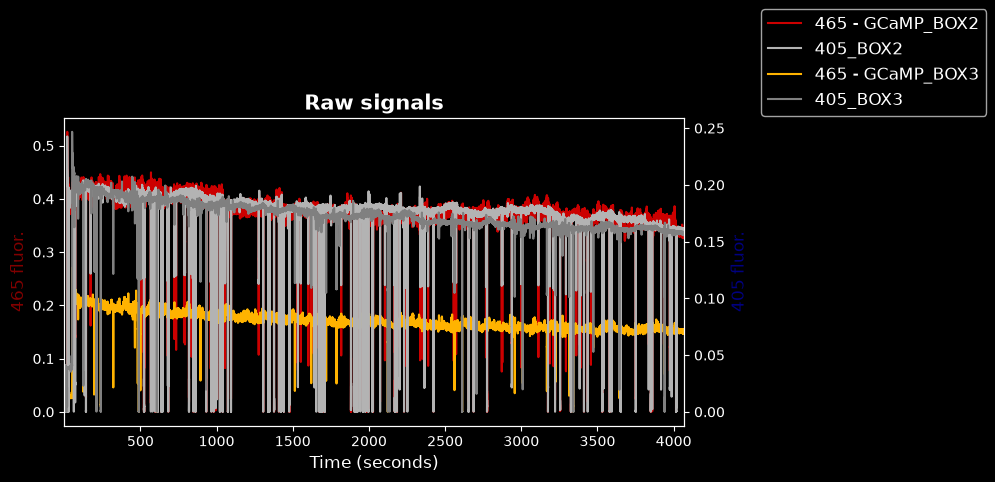

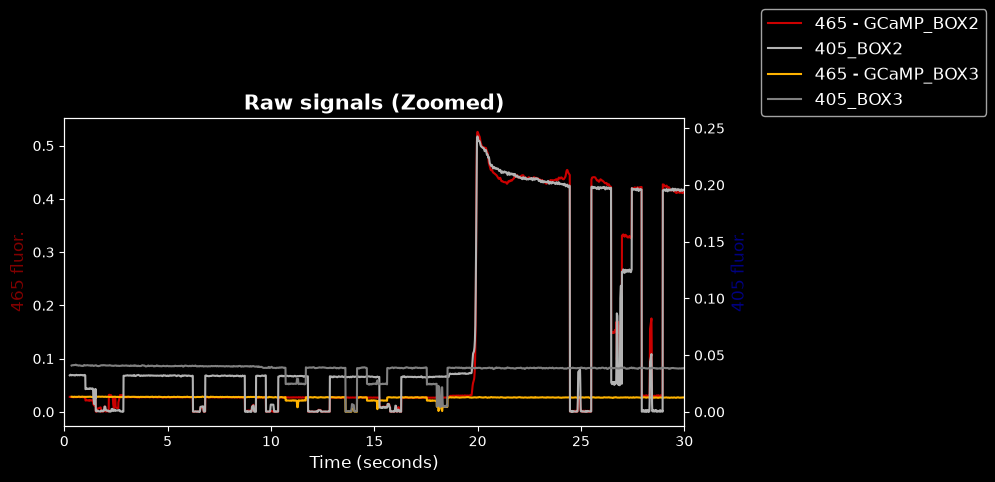

In [4]:

# visualize the raw data and begin to define some key variable (e.g. sampling rate, fs)

from fp_func_acw import streams_peek_ratpack_tdt_or_doric

#_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-


# Define the box of interest to further process
box = 'BOX3'  

#_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-


box_to_rat = {
    'BOX2': BOX2_rat,
    'BOX3': BOX3_rat,
    'BOX4': BOX4_rat,
    'BOX5': BOX5_rat,
}


print(box_to_rat)


rat_data, fs, ts_dict, fig_0, fig_1, data_format = streams_peek_ratpack_tdt_or_doric(
    streams_info,
    streams_data,
    box_to_rat,
    zoomtemp = [0, 30]
)


# Look up the rat name for this box
rat = box_to_rat[box]

# Extract the signals for this rat from the rat_data dictionary
isos_405_all = rat_data[rat]['isos_405']
GCaMP_465_all = rat_data[rat]['GCaMP_465']
ts_all = ts_dict[box]  # Get the corresponding time vector for that box


display(rat_data)

print(f'The rat to be further examined is: {rat}')


# detect and remove artifacts in the stream data

# filter and downsample the stream data 

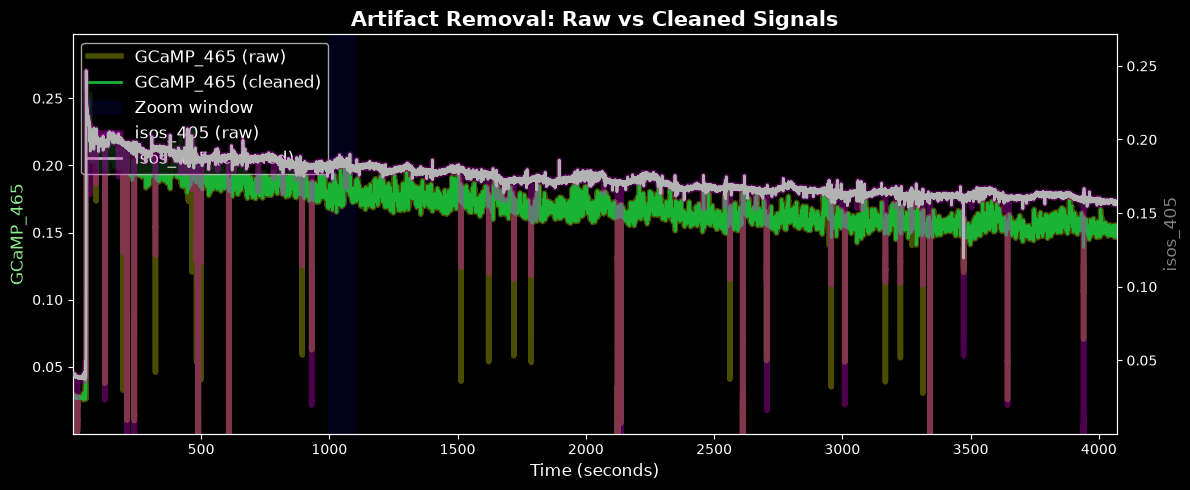

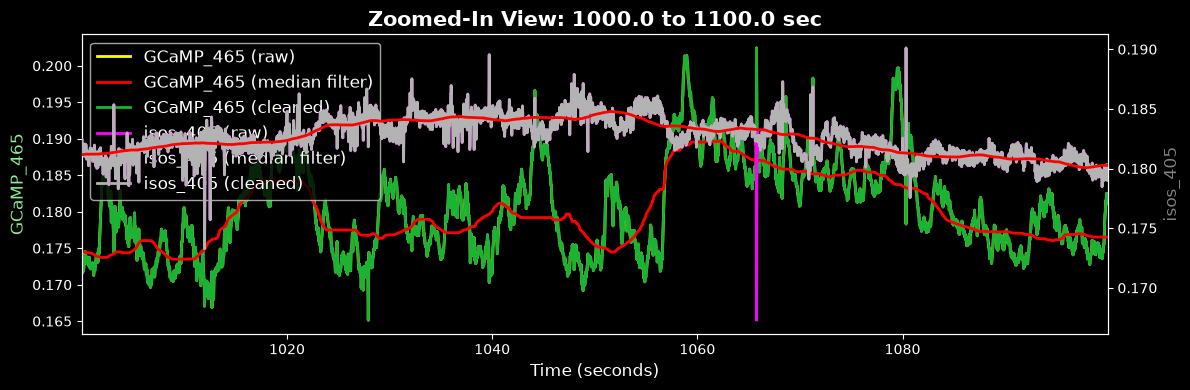

20.0
isos_405 length: 406780
isos_405_downsamp length: 81387
GCaMP_465 length: 406780
GCaMP_465_downsamp length: 81387
ts_all length: 406780
ts_downsamp length: 81387

the duration of the stream data is 4069.6522689899994 seconds, aka 67.82753781649998 mins


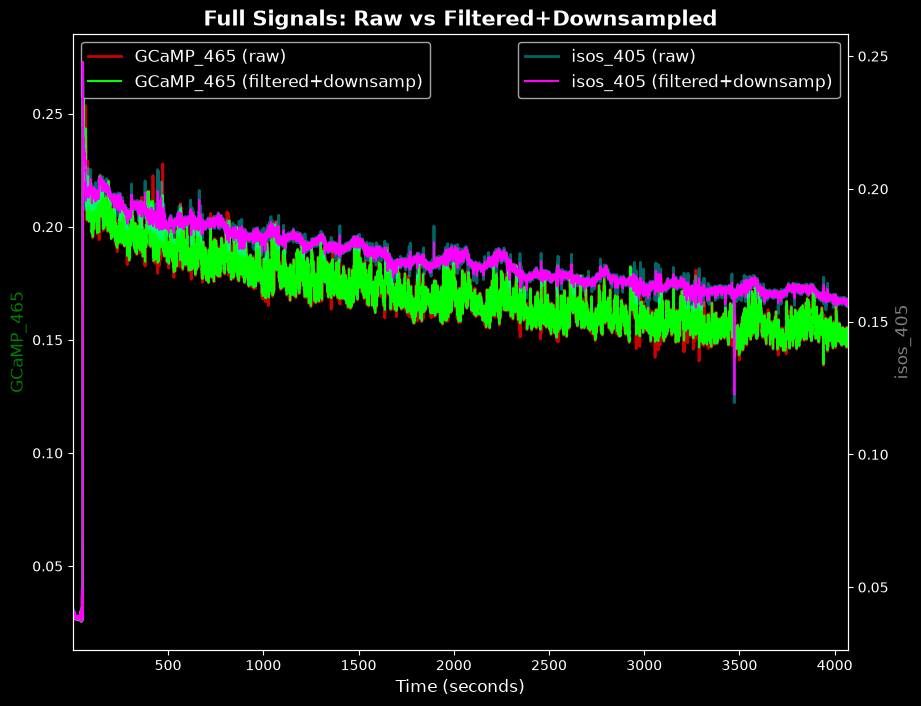

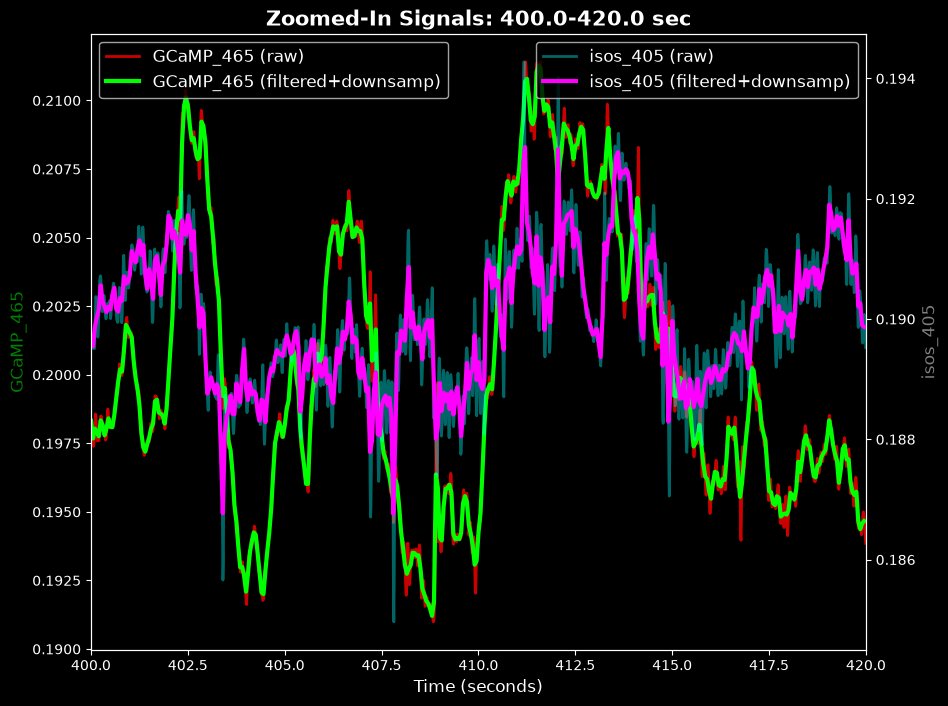

In [5]:
# these functions perform initial pre-processing: detection of artifacts and removal via linear interpolation, low-pass filtering, and downsampling 

from fp_func_acw import remove_artifacts_dual_signal

GCaMP_465_all_no_arts, isos_405_all_no_arts = remove_artifacts_dual_signal(
    ts_all,
    GCaMP_465_all,
    isos_405_all,
    threshold_drop_signal1=0.10,           # amplitude drop threshold for GCaMP
    threshold_drop_signal2=0.05,           # amplitude drop threshold for isosbestic
    sudden_drop_threshold_signal1=0.02,     # sudden drop threshold for GCaMP
    sudden_drop_threshold_signal2=0.02,    # sudden drop threshold for isosbestic+
    min_artifact_duration=1,                # minimum artifact length in samples
    max_artifact_duration=5000,              # max artifact length in samples
    sampling_rate=100,  
    median_filter_size=1000,
    baseline_exclusion_seconds=0,# <-- ignore first seconds for artifact detection
    manual_windows=None, #[(2135, 2150)], #[(3225,3235)],    # list of tuples
    plot=True,
    signal1_label='GCaMP_465',
    signal2_label='isos_405',
    zoom_start = 1000,
    zoom_window = 100
)


# Downsample and average via a moving window mean


from fp_func_acw import filt_downsamp_streams

#new_fs = fs/50  # this yields a new sampling rate of approximately 20 Hz, for tdt recordings (~1017 Hz)

new_fs = fs/5  # sampling rate of 20 Hz for Doric data, which saves the demodulated signals at 100 Hz.

filt = 8   # cutoff for the low-pass filter

print(new_fs)

isos_405_filt_downsamp, GCaMP_465_filt_downsamp, ts_downsamp, fig_8, fig_zoom = filt_downsamp_streams(
    isos_405_all_no_arts, 
    GCaMP_465_all_no_arts, 
    ts_all, fs, 
    new_fs,
    filt,
    zoom_start=400, 
    zoom_window=20
)

print("isos_405 length:", isos_405_all.size)
print("isos_405_downsamp length:", isos_405_filt_downsamp.size)
print("GCaMP_465 length:", GCaMP_465_all.size)
print("GCaMP_465_downsamp length:", GCaMP_465_filt_downsamp.size)
print("ts_all length:", ts_all.size)
print("ts_downsamp length:", ts_downsamp.size)

print()
print(f'the duration of the stream data is {ts_downsamp[-1]} seconds, aka {ts_downsamp[-1]/60} mins')


## visualize the event TTLs, trimming and filtering streams

## filter the epoc_data to examine the events occurring during the photometry time segment of interest

detected data format: Doric
using epoc data file at: D:\ACW\photometry\cohort_5_101325\extracted\CR\coh5b\processed_sessions\processed_sessions\ACW_coh5b_111425_0001_epocs_data.feather


,blockname,source_path,input code,onset
33,ACW_coh5b_111425_0001,Series0001/DigitalIO/DIO13,D13 Raw_DrugAvail_box3,395.313
34,ACW_coh5b_111425_0001,Series0001/DigitalIO/DIO14,D14 Raw_ActiveLever_box3,410.143
35,ACW_coh5b_111425_0001,Series0001/DigitalIO/DIO14,D14 Raw_ActiveLever_box3,433.214
36,ACW_coh5b_111425_0001,Series0001/DigitalIO/DIO14,D14 Raw_ActiveLever_box3,434.184
37,ACW_coh5b_111425_0001,Series0001/DigitalIO/DIO14,D14 Raw_ActiveLever_box3,435.114
...,...,...,...,...
135,ACW_coh5b_111425_0001,Series0001/DigitalIO/DIO14,D14 Raw_ActiveLever_box3,3629.416
136,ACW_coh5b_111425_0001,Series0001/DigitalIO/DIO15,D15 Raw_InactiveLever_box3,670.674
137,ACW_coh5b_111425_0001,Series0001/DigitalIO/DIO15,D15 Raw_InactiveLever_box3,3009.240
138,ACW_coh5b_111425_0001,Series0001/DigitalIO/DIO15,D15 Raw_InactiveLever_box3,3014.121



📋 Unique D## codes found: <ArrowStringArray>
['D09', 'D10', 'D11', 'D13', 'D14', 'D15']
Length: 6, dtype: str
📌 dropsec_code reflects beginning of the Med Associates program
📌 dropsec_code reflects onset of drug availability

⏱ dropsec code D13 corresponds to timepoints: [395.313]

✅ Using dropsec = 395.313 seconds from epoc data.
the downsampled sampling rate is 20.0 Hz

discard the first 395.313 seconds, data points from 0 to 7906

keep a duration of 60 minutes
Selected indices, included interval: start=7700, end=80200 (60.42 min)

- - - - - initial vector lengths - - - - -

len(isos_405_filt_downsamp): 81387
len(ts_downsamp): 81387

start index: 7700
end index: 80200

Trimmed duration: 3624.95 sec (~60.42 min) (requested 60 min, pre_buffer 10s, post_buffer 15s)

Plotting segment (60 min starting at TTL, ±10/15 s buffer) ...

- - - - - examining 60 minutes of the epoc data - - - - - 

the dropsec code is D13
the start code is 0
parent: cr
cued reinstatement epoc_ts_and_indices:


ACW_coh5_IT_m4 epoc timestamps,epoc_ts,epoc_indices,data,event
0,0.000,200,D13,program start
1,14.830,496,D14,active lever
2,37.901,958,D14,active lever
3,38.871,977,D14,active lever
4,39.801,996,D14,active lever
...,...,...,...,...
158,3030.234,60804,NaN,missed infusion
159,3049.555,61191,NaN,missed infusion
160,3066.466,61529,NaN,missed infusion
161,3182.261,63845,NaN,missed infusion


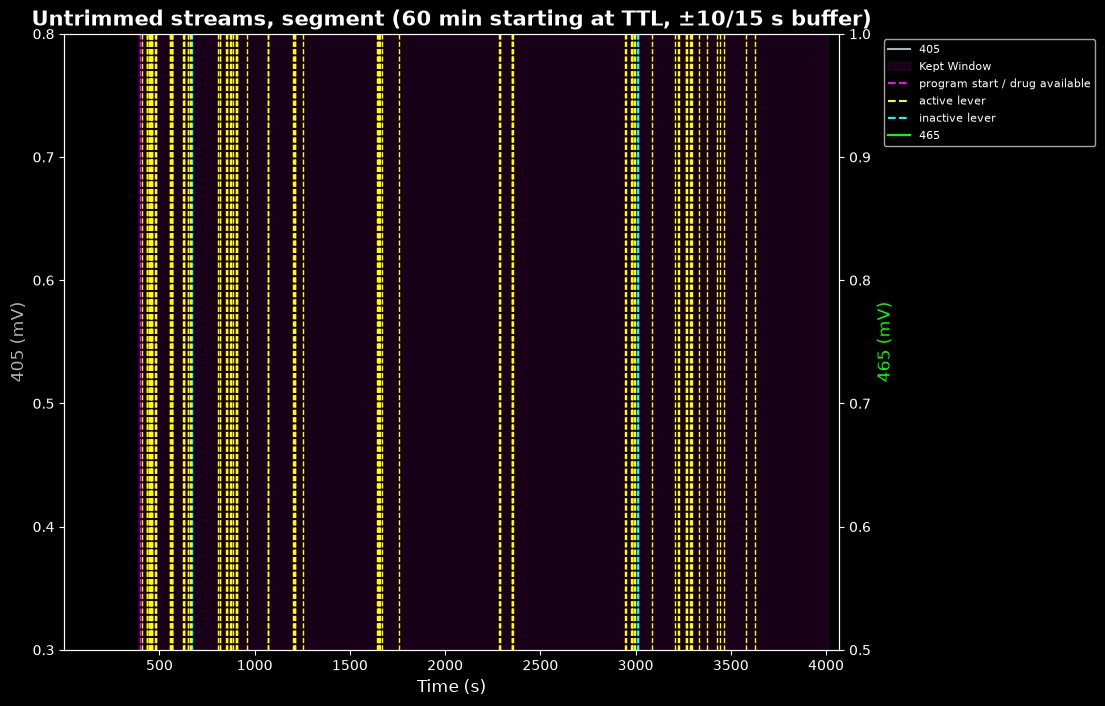

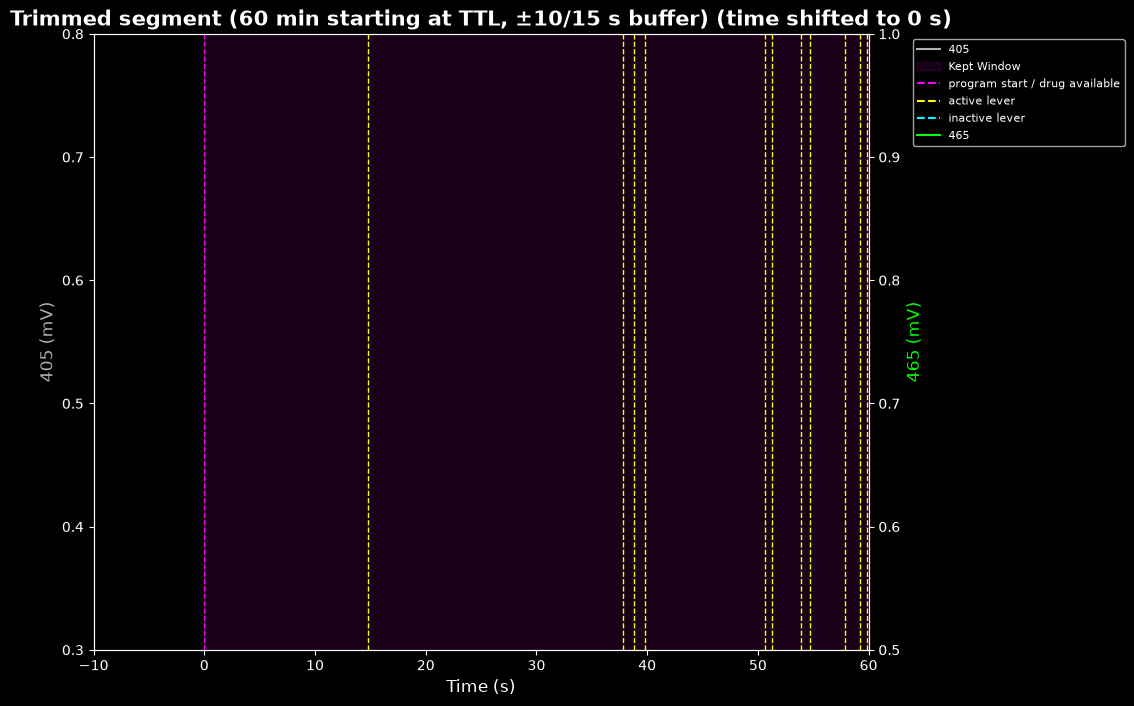

In [6]:
# this code block is used to load the event timestamps and identifying information
# additionally, the photometry data is trimmed to a specified duration
# the timespan to be further analyzed is defined based on behavioral or task events represented by the event timestamps
# for example, during intermittent-access self-admin sessions, the onset of drug availability is signaled by a TTL 
  ## if the objective is to examine the photometry signal during the 5 min available period, one uses segment mode "during" and defines "keepmin_streams" as 5. 

# photometry data preceding and following the window of interest is discarded, and all photometry and event timestamp data is aligned such that ts = 0 at the beginning of the specified interval
# segment modes can be selected to keep photometry data preceding the availability onset, following the available period, or capturing both transitions

#_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-



if data_format == 'Doric':
    from fp_func_acw import streams_trim_events_doric
    
    print('detected data format: Doric')
    
    # Analysis parameters


    default_dropsec = 10  # seconds

    startcode = 0     # This is 0 except in cases like IntA where there are multiple possible starts

    #dropsec_code = 'D09' # for the new Med PC programs, beginning 10.01.25

    if box == 'BOX2':
        dropsec_code = 'D09'
        
    elif box == 'BOX3':
        dropsec_code = 'D13'
            
    elif box == 'BOX4':
        dropsec_code = 'D25'
            
    elif box == 'BOX5':
        dropsec_code = 'D29'

    
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~#
    
    keepmin_streams = 60 # mins
    
    segment_mode = None     ####### 'before', 'during', or 'after' for either unavail preceding, avail, or unavail following. 
                            # or 'transitions'
                            ## or None if not an intermittent access file
            
            
    if segment_mode == 'during':
        pre_buffer_sec = 30 # seconds
        post_buffer_sec = 15 # seconds
        tzoom=[-30,30]
        
    elif segment_mode == None:
        pre_buffer_sec = 10 # seconds
        post_buffer_sec = 15 # seconds
        tzoom=[-10,60]
        
    elif segment_mode == 'transitions':
        pre_buffer_sec = 0 # seconds
        post_buffer_sec = 0 # seconds
        tzoom=[50,75]
        
    else:
        pre_buffer_sec = 0 # seconds
        post_buffer_sec = 0 # seconds
        tzoom=[-10,15]
    
    
    
    # Try to load epoc data and determine dropsec_streams

    epoc_data = None
    dropsec_streams = default_dropsec

    try:
        #epoc_data_path = os.path.join(subcoh + session_id + '_epocs_data.feather')  # already loaded above
        #epoc_data = pd.read_feather(epoc_data_path)
        # Path to the moved file
        epoc_data_path = os.path.join(subcoh, "processed_sessions", f"{session_id}_epocs_data.feather")

        # Load epoc data if it exists
        if os.path.exists(epoc_data_path):
            print(f'using epoc data file at: {epoc_data_path}')
            epoc_data = pd.read_feather(epoc_data_path)
            display(epoc_data[epoc_data['input code'].str.contains(box, case=False, na=False)])
        else:
            print(f"Epoc data file not found in processed_sessions: {epoc_data_path}")
            epoc_data = None


        # 🔍 DEBUG: Show unique TTL codes for the current box
        # Extract the D## part from the 'input code' column
        epoc_data['D_code'] = epoc_data['input code'].str.extract(r'^(D\d{2})')

        # Get unique D## codes
        unique_d_codes = epoc_data['D_code'].dropna().unique()

        # Display the result
        print(f"\n📋 Unique D## codes found: {unique_d_codes}")
        
        # Extract onsets for the selected TTL code
        # Define the allowed D## codes
        allowed_d_codes = ['D09', 'D13', 'D25', 'D29']

        # Filter the DataFrame
        filtered_rows = epoc_data[
            epoc_data['input code'].str.contains(box, case=False, na=False) &  # case-insensitive match to box
            epoc_data['input code'].str.extract(r'^(D\d{2})')[0].isin(allowed_d_codes)  # extract D## and filter
        ]

        # Extract onset values
        dropsec_all = filtered_rows['onset'].values
        
        
        # 🧾 Interpret the TTL code
        if dropsec_code in ['D09', 'D13', 'D25', 'D29']:
            print('📌 dropsec_code reflects beginning of the Med Associates program')

        if dropsec_code in ['D09', 'D13', 'D25', 'D29'] and epoc_data['input code'].str.contains('Avail').any():
            print('📌 dropsec_code reflects onset of drug availability')
        

        print(f'\n⏱ dropsec code {dropsec_code} corresponds to timepoints: {dropsec_all}\n')

        # Select the event instance to use
        if len(dropsec_all) > startcode:
            dropsec_streams = dropsec_all[startcode]
            print(f'✅ Using dropsec = {dropsec_streams:.3f} seconds from epoc data.')
        else:
            dropsec_streams = default_dropsec
            pre_buffer_sec = 0 # seconds
            post_buffer_sec = 0 # seconds
            print(f'⚠️ No TTL onset found at index {startcode}. Using default dropsec = {default_dropsec} seconds, no buffers')

            
    except FileNotFoundError as e:
        dropsec_streams = default_dropsec
        epoc_data = None
        print(f'\n⚠️ Missing file "{e.filename}". Using default dropsec = {default_dropsec} seconds.')

    except Exception as e:
        dropsec_streams = default_dropsec
        epoc_data = None
        print(f'\n⚠️ Unexpected error: {e}. Using default dropsec = {default_dropsec} seconds.')



    #print(f'\nThe time segment preceding the trial begin is {dropsec_streams} seconds.')

    if 'noncont' in subcoh:
        noncont = True
    else:
        noncont = False



    # Bounds for final plot
    x = [0, 10]
    y1 = [(0.9 * np.mean(GCaMP_465_filt_downsamp)), (1.1 * np.mean(GCaMP_465_filt_downsamp))]
    y2 = [(0.9 * np.mean(isos_405_filt_downsamp)), (1.1 * np.mean(isos_405_filt_downsamp))]




    # Run stream trimming
    
    fig_2a, fig_2b, isos_405, GCaMP_465, ts = streams_trim_events_doric(
        isos_405_filt_downsamp,
        GCaMP_465_filt_downsamp,
        dropsec_streams,
        keepmin_streams,
        ts_downsamp,
        new_fs,
        y1,
        y2,
        x,
        startcode,
        epoc_data=epoc_data,  # can now safely be None
        box=box,
        noncont=False,
        tzoom=tzoom,
        segment_mode = segment_mode,
        pre_buffer_sec=pre_buffer_sec, 
        post_buffer_sec=post_buffer_sec
    )

    
    

#_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-

# use the below for behavioral events during self-admin paradigm


from fp_func_acw import epoc_onsets_FR    # this function uses the event codes for the FR_1 training sessions

from fp_func_acw import epoc_onsets_noncont     # this function uses the event codes for the noncontingent cue sessions

from fp_func_acw import epoc_onsets_IntA     # this function uses the event codes for the IntA self-admin

from fp_func_acw import epoc_onsets_PR     # this function uses the event codes for the progressive ratio test

from fp_func_acw import epoc_onsets_ext    # this function uses the event codes for the extinction sessions

from fp_func_acw import epoc_onsets_CR     # this function uses the event codes for the cued reinstatement



#_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-



####  importantly, these codes should match those above for the stream trimming!

keepmin_epocs = keepmin_streams   # what is the duration in minutes of the epoc data I want to examine? 
#keepmin_epocs = 90 # if I want to see all events


print(f'\n- - - - - examining {keepmin_epocs} minutes of the epoc data - - - - - \n')

dropsec_code = dropsec_code   # inherited from above. this is 1 for most cases, beginning of med pc program, but is 3 for start of IntA and 2 for remaining available periods

print(f'the dropsec code is {dropsec_code}')

startcode = startcode    # again, inherited from above. which index of dropsec_code to use, if there are multiple options. E.g. 1 would be the index for the second drug available onset. 

print(f'the start code is {startcode}')

#### 

 
#_-_-_-_-_-_-_-_-_-_-_-_-_- _-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-


# Get the *parent* folder name (e.g. "IntA_SA")
#parent = os.path.basename(os.path.dirname(subcoh)).lower()
parent = Path(subcoh).parents[1].name.lower()
print(f'parent: {parent}')

if "training" in parent:
    epoc_ts_and_indices, ts_epocs = epoc_onsets_FR(epoc_data, keepmin_epocs, ts, box, new_fs, dropsec_streams, data_format)
    print('training epoc_ts_and_indices:')

elif "noncont" in parent:
    epoc_ts_and_indices, ts_epocs = epoc_onsets_noncont(epoc_data, keepmin_epocs, ts, box, new_fs, dropsec_streams, data_format)
    print('noncontingent cue presentations epoc_ts_and_indices:')

elif "inta_sa" in parent:
    epoc_ts_and_indices, ts_epocs = epoc_onsets_IntA(epoc_data, keepmin_epocs, ts, box, new_fs, dropsec_streams, segment_mode, data_format)
    print('Intermittent access self-admin epoc_ts_and_indices:')

elif "pr" in parent:
    epoc_ts_and_indices, ts_epocs = epoc_onsets_PR(epoc_data, keepmin_epocs, ts, box, new_fs, dropsec_streams, data_format)
    print('progressive ratio epoc_ts_and_indices:')

elif "extinction" in parent:
    epoc_ts_and_indices, ts_epocs = epoc_onsets_ext(epoc_data, keepmin_epocs, ts, box, new_fs, dropsec_streams, data_format)
    print('extinction epoc_ts_and_indices:')

elif parent == "cr":
    epoc_ts_and_indices, ts_epocs = epoc_onsets_CR(epoc_data, keepmin_epocs, ts, box, new_fs, dropsec_streams, data_format)
    print('cued reinstatement epoc_ts_and_indices:')

# to view the indices of each epoc onset

epoc_ts_and_indices.columns.name = f'{rat} epoc timestamps'
display(epoc_ts_and_indices)


  

## remove light artifacts if necessary



Detected 56 artifact segments.


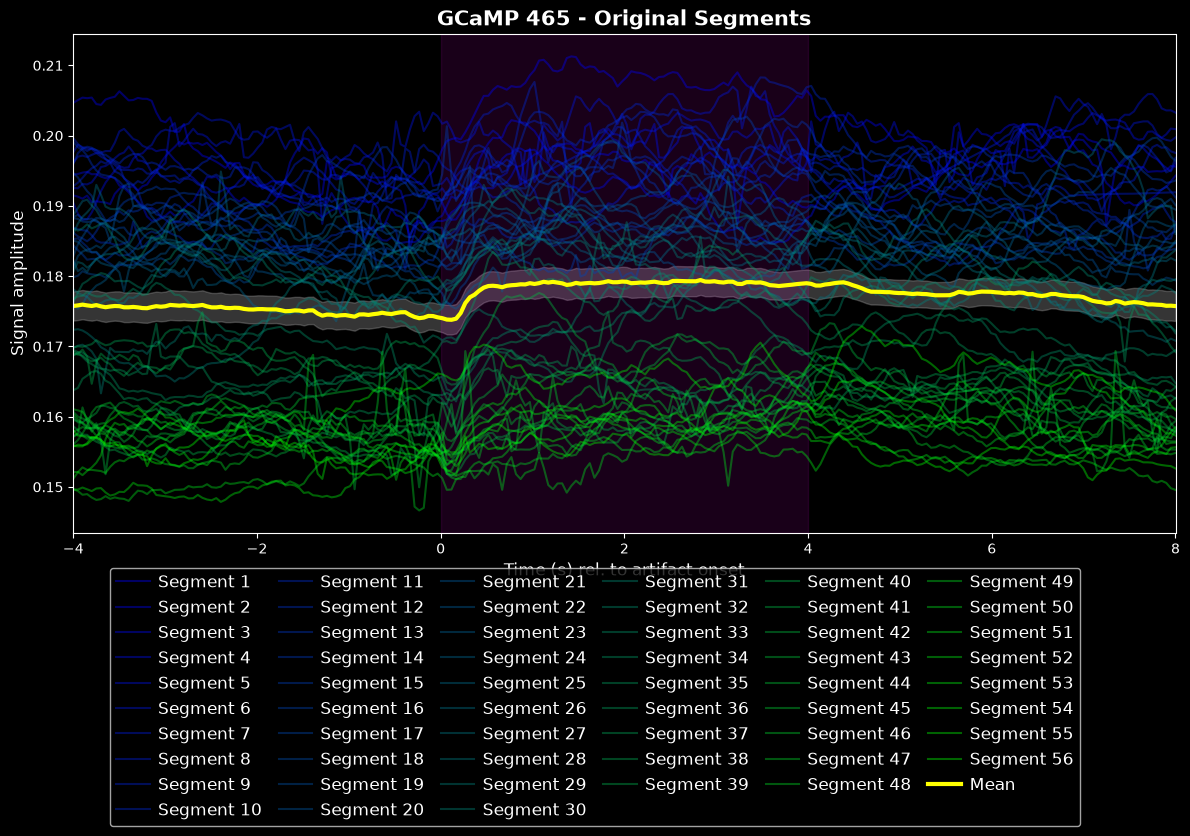

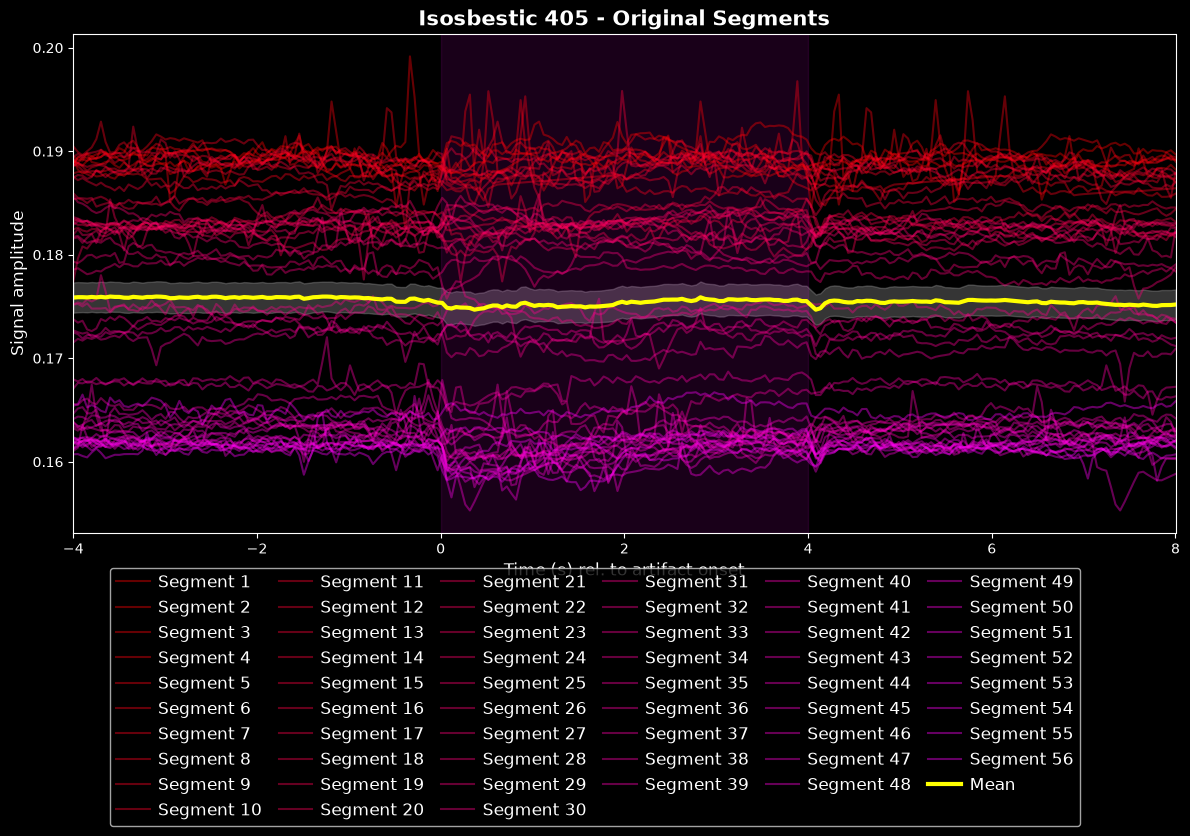

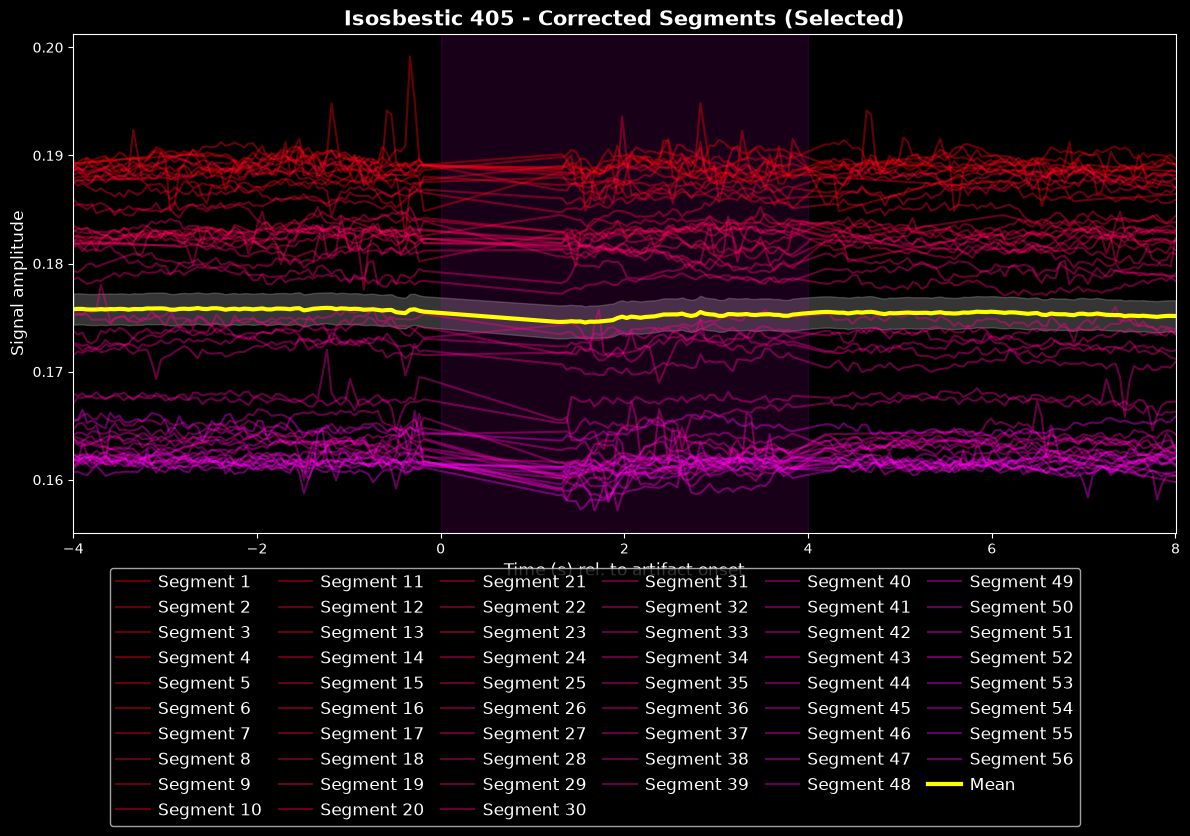

In [7]:
from fp_func_acw import visualize_and_correct_artifacts


correct_stream='isos'


GCaMP_465_nocuearts, isos_405_nocuearts = visualize_and_correct_artifacts(
    epoc_ts_and_indices,
    new_fs,
    ts,
    GCaMP_465,
    isos_405,
    correct_stream=correct_stream,
    segments_to_correct=None,           # list of segment indices to correct (1-based) # e.g. [1,2,4,5] for subset, or "None" for all
    baseline_window_sec=2,
    artifact_duration_sec=4,          # customizable artifact duration, typically 4 sec but sometimes shorter
    buffer_sec=0.15,                   # how much time (sec) to smooth at artifact edges
    interpolation_ranges_sec=[(-0.2,1.3),(3.8,4.2)],      # list of tuples, e.g., [(-0.2, 0.2), (3.8, 4.2)] or None
    interpolation_position='both',
    correction_mode='both'       # options: 'offset', 'interpolate', 'both', 'none'

)



## motion correction using a linear fit between isosbestic and GCaMP streams

## Correct photobleaching for isosbestic and 465 channels by subtracting a double exponential fit 

## Correct for photobleaching, baseline drift using an adaptive iteratively reweighted penalized least squares algorithm (airPLS)


## normalization by Z-scoring (subtract the mean, divide by the standard deviation) and dF/F (subtract the motion correction, then divide by the estimated motion from above)

Detected 56 perievent segments.


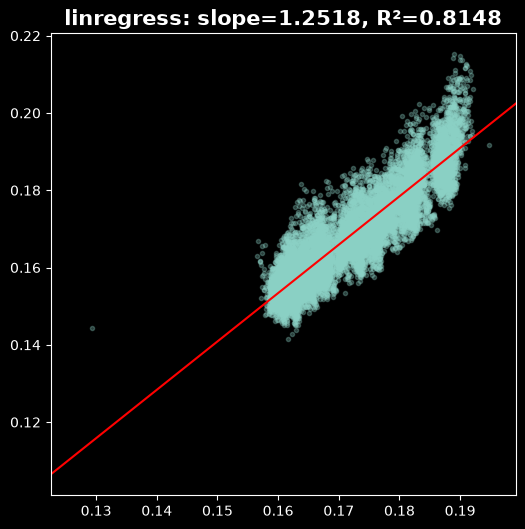

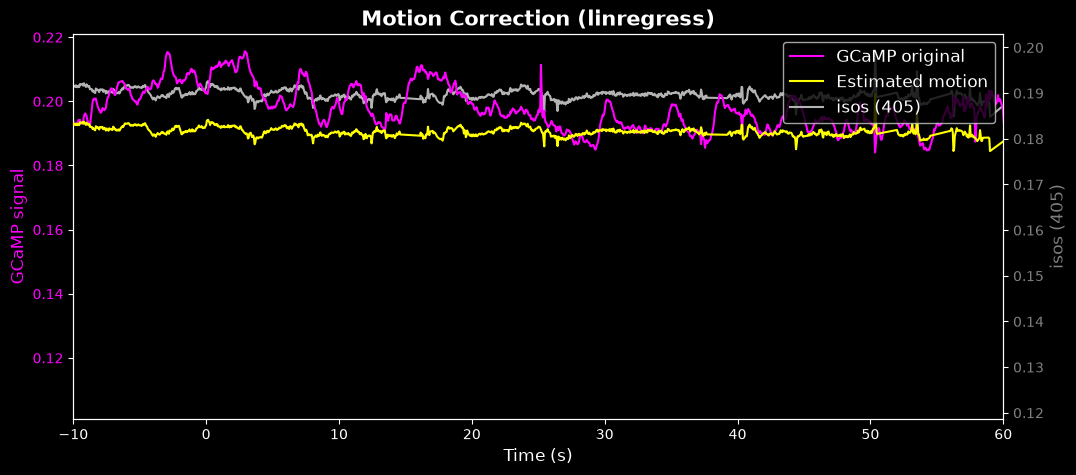

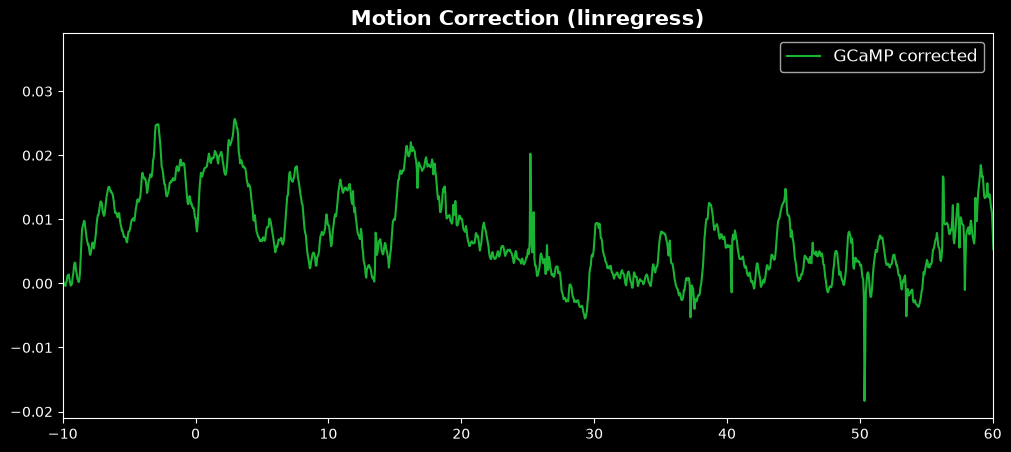

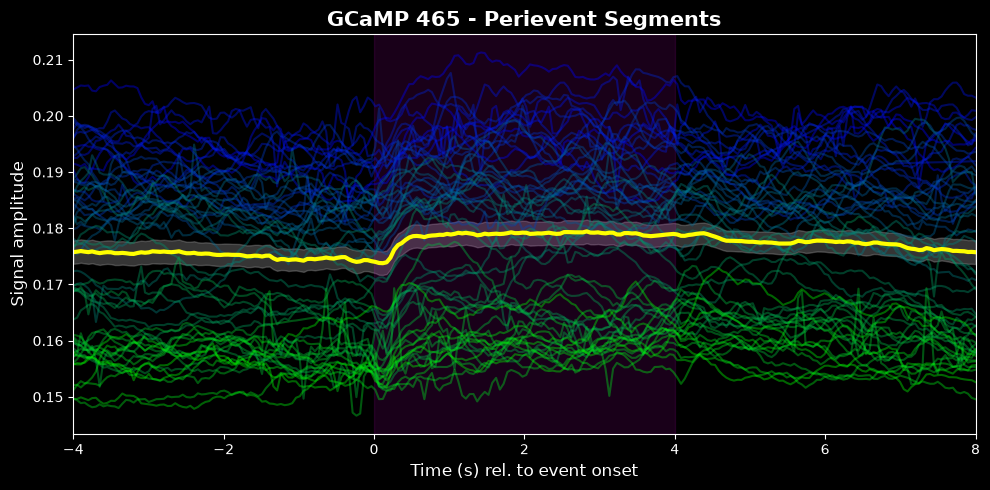

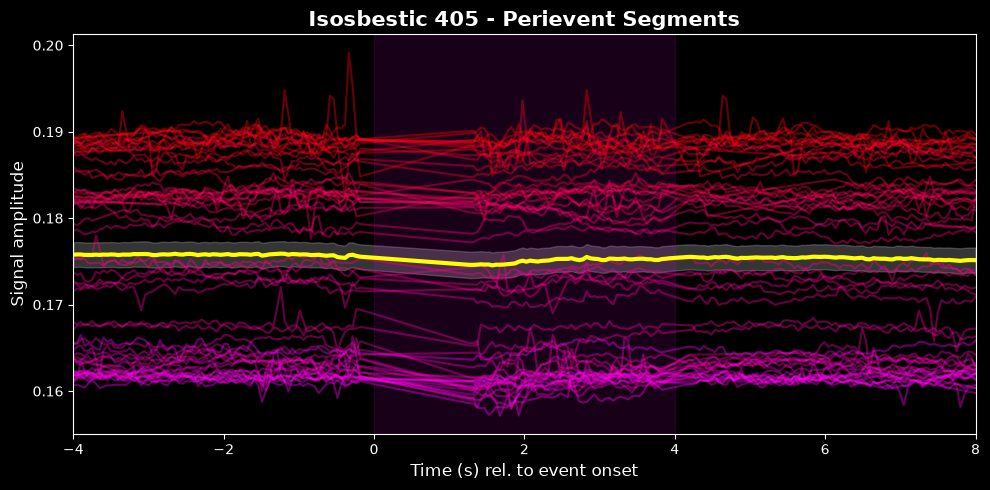

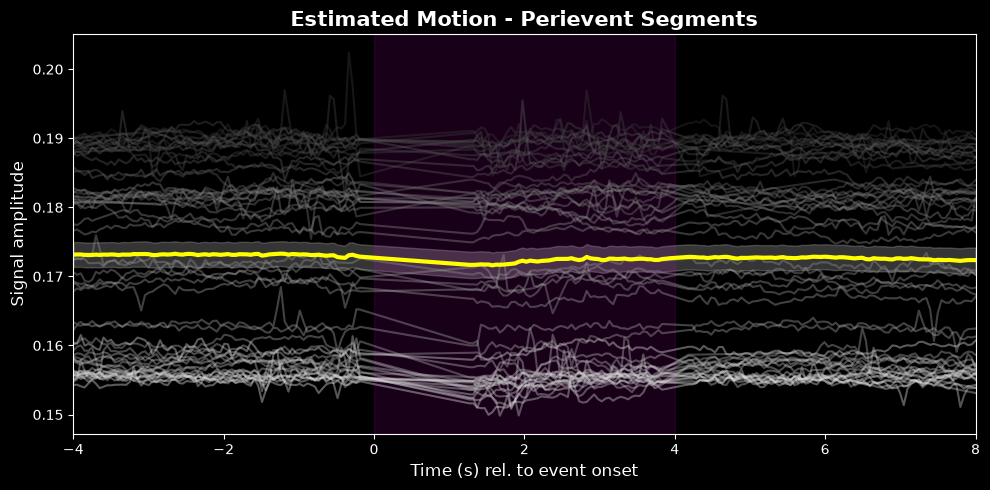

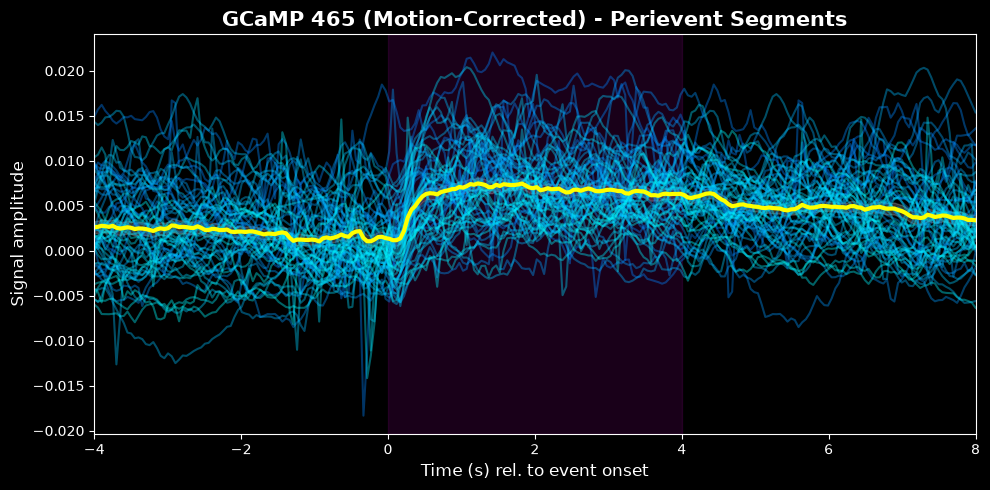

ACW_coh5_IT_m4 preprocessed streams,ts,isosbestic 405nm,"isosbestic 405nm, artifacts corrected",GCaMP 465nm,estimated motion,GCaMP 465nm motion correction,"GCaMP 465nm motion correction, exponential fit","GCaMP 465nm motion correction, exponential fit, airPLS","GCaMP 465nm motion correction, exponential fit, airPLS, z-scored","GCaMP 465nm, dF/F",isosbestic 405nm exponential fit,"isosbestic 405nm exponential fit, airPLS","isosbestic 405nm exponential fit, airPLS, z-scored"
0,-10.00,0.191701,0.191701,0.194012,0.193080,0.000932,-0.011454,-0.009596,-1.950499,0.482734,0.001185,0.001672,1.632783
1,-9.95,0.191472,0.191472,0.193021,0.192794,0.000227,-0.012151,-0.010293,-2.092363,0.117786,0.000956,0.001444,1.410003
2,-9.90,0.191608,0.191608,0.192791,0.192963,-0.000172,-0.012543,-0.010685,-2.172056,-0.089134,0.001092,0.001579,1.542658
3,-9.85,0.191392,0.191392,0.192611,0.192693,-0.000082,-0.012446,-0.010588,-2.152265,-0.042348,0.000877,0.001365,1.332733
4,-9.80,0.191730,0.191730,0.192694,0.193115,-0.000422,-0.012779,-0.010921,-2.220015,-0.218430,0.001216,0.001703,1.663320
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72495,3614.75,0.157819,0.157819,0.157035,0.150667,0.006368,0.006368,0.003561,0.723772,4.226869,-0.001717,-0.001062,-1.036780
72496,3614.80,0.158044,0.158044,0.157504,0.150948,0.006556,0.006556,0.003748,0.761829,4.343105,-0.001492,-0.000837,-0.817167
72497,3614.85,0.157983,0.157983,0.158228,0.150872,0.007357,0.007357,0.004549,0.924594,4.876111,-0.001553,-0.000897,-0.876346
72498,3614.90,0.157791,0.157791,0.158987,0.150631,0.008357,0.008357,0.005548,1.127825,5.547728,-0.001745,-0.001089,-1.064029


r = 0.9240
slope = 0.2916
intercept = -0.0007
R² = 0.8537
Correlation between z(dF/F) and z-score = 0.9240


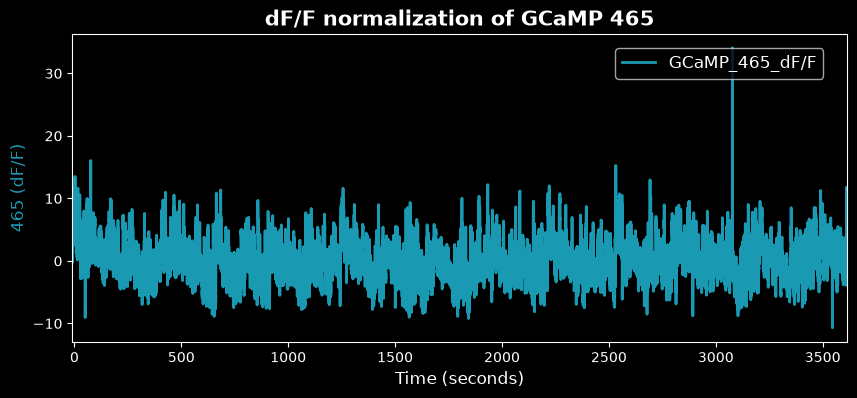

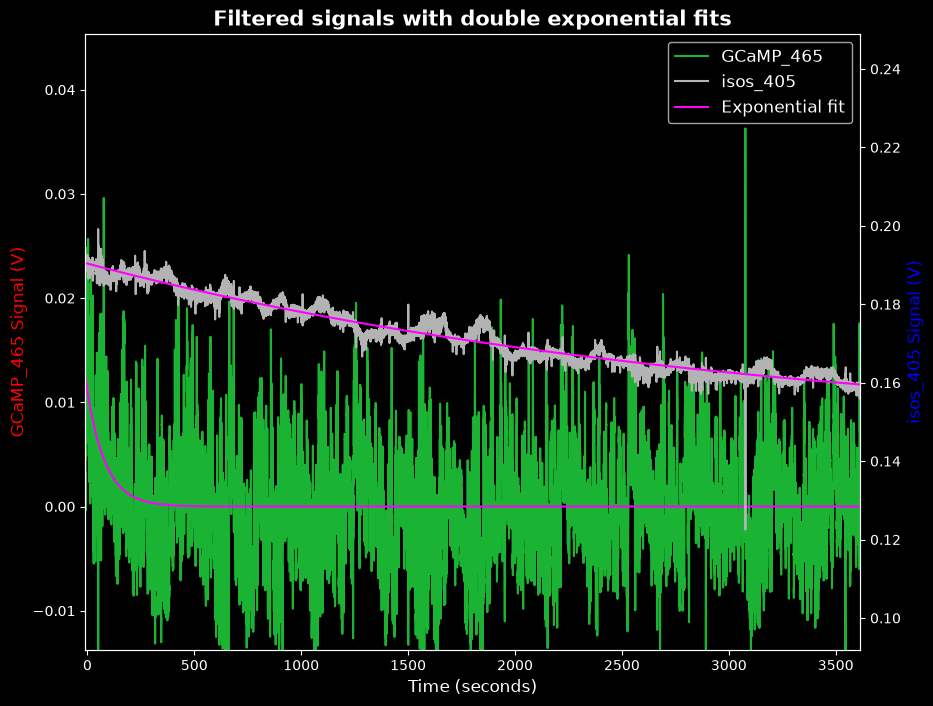

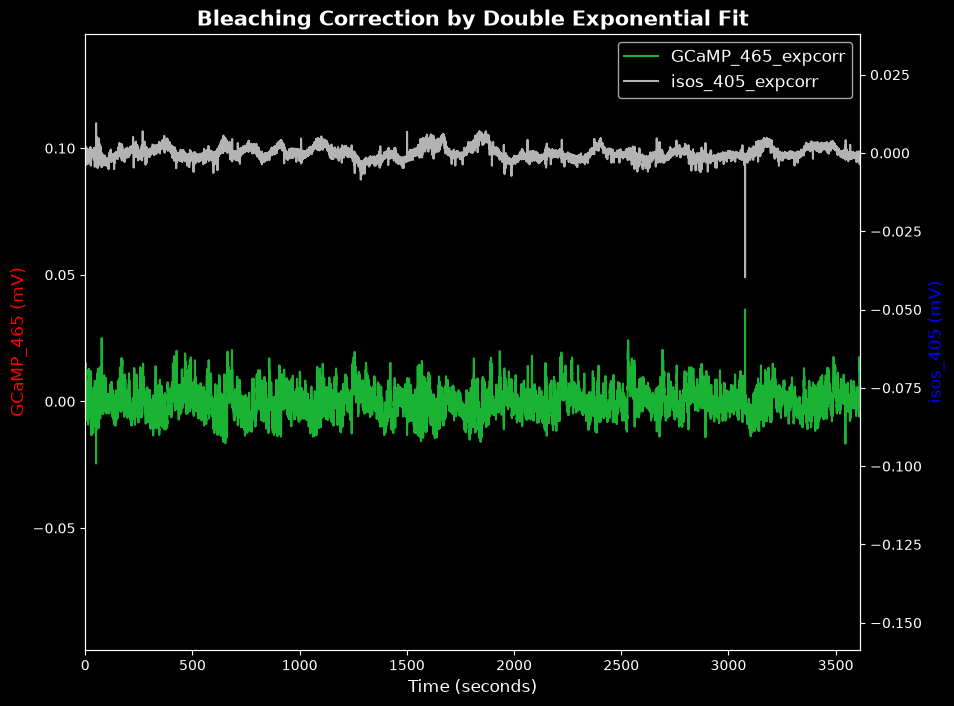

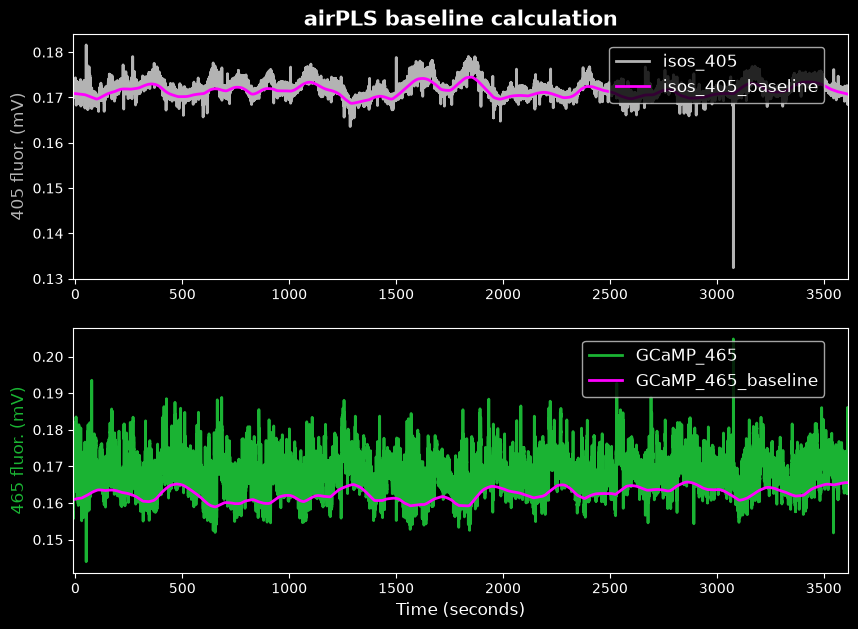

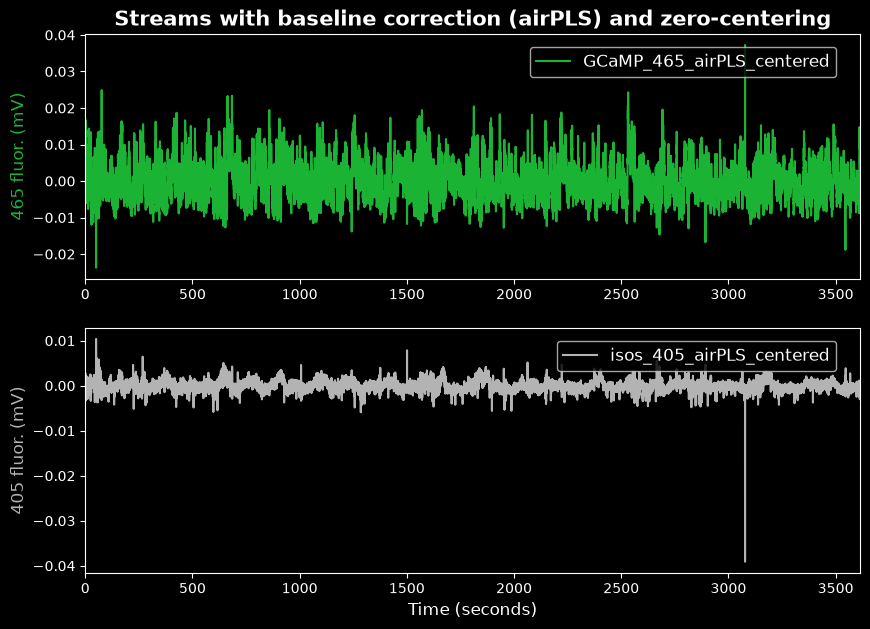

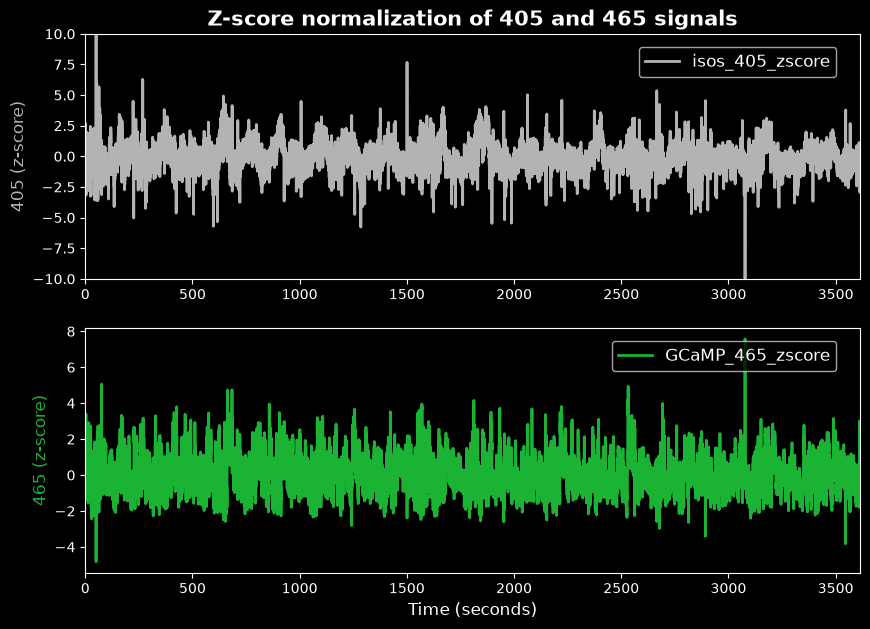

<Figure size 1000x700 with 0 Axes>

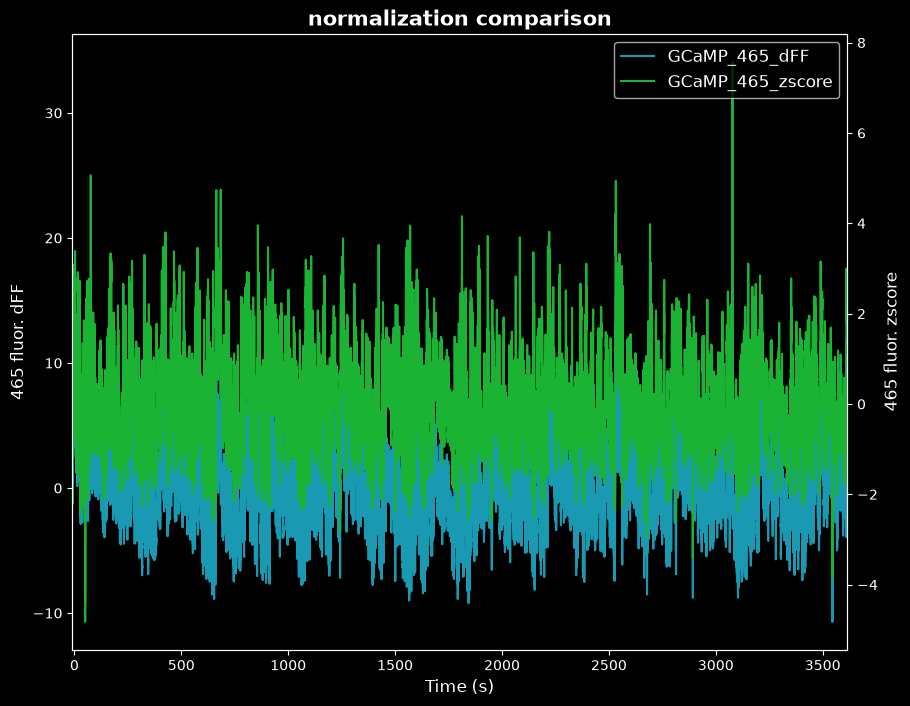

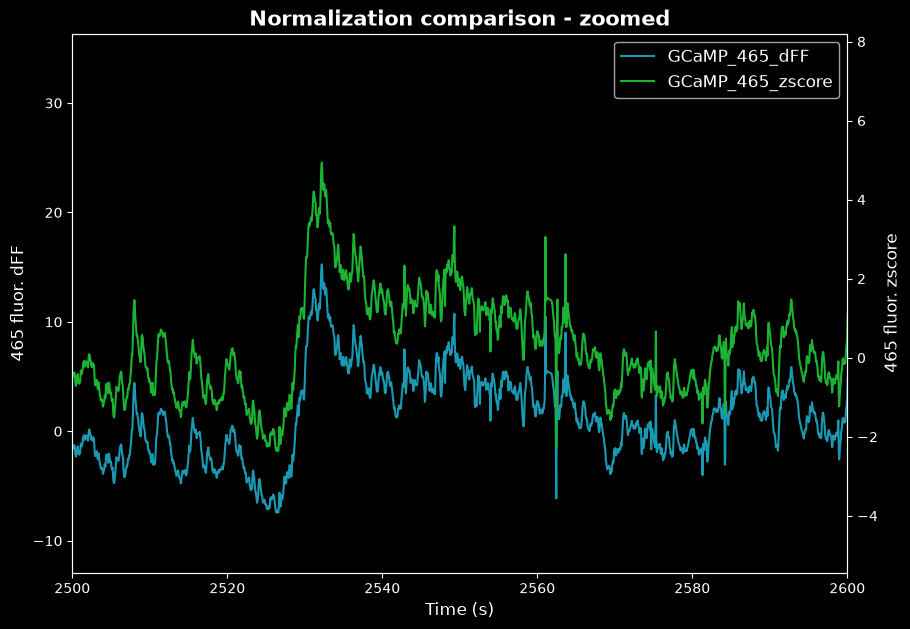

In [8]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

## motion correction using a linear fit between isosbestic and GCaMP streams


from fp_func_acw import motcorr_unified

# Time vector and zoom window
#tzoom = (500,750)  # example limits in seconds
tzoom = (-10,60)


# ---  Linear regression or polyfit motion correction ---
GCaMP_465_motcorr, est_motion, slope_linreg, intercept_linreg, r2_linreg, figs_linreg = motcorr_unified(
    ts=ts,
    isos=isos_405_nocuearts,
    gcamp=GCaMP_465,
    tzoom=tzoom,
    method="linregress",  #'linregress' or 'polyfit' 
    clamp_negative=True,
    r2_threshold=0.0001,
    plot=True
)


if segment_mode == 'transitions':
    event_filter='drug available'
    
elif segment_mode == 'during':
    event_filter='infusion'
    
elif segment_mode == None:
    event_filter= 'infusion|cue light'

elif segment_mode in ['before', 'after']:
    event_filter='active lever'

    
from fp_func_acw import plot_perievent_segments

plot_perievent_segments(
    epoc_ts_and_indices=epoc_ts_and_indices,    # your DataFrame with event timestamps
    new_fs=new_fs,                                  # your sampling frequency
    ts=ts,                                      # your full time vector
    GCaMP_465=GCaMP_465,                        # raw GCaMP signal
    isos_405_nocuearts=isos_405_nocuearts,     # isosbestic signal without cue artifacts
    est_motion=est_motion,                      # estimated motion signal
    GCaMP_465_motcorr=GCaMP_465_motcorr,      # motion-corrected GCaMP signal
    event_filter=event_filter,
    pre_window_sec=4.0,
    post_window_sec=8.0
)

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# compute the dF/F normalization of the GCaMP signal using the est_motion from motcorr_unified

from fp_func_acw import deltaFF

GCaMP_465_dFF = deltaFF(GCaMP_465, est_motion, ts)


#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Further process the motion-corrected signal to correct baseline drift, photobleaching, etc.
# Correct photobleaching for isosbestic and 465 channels by subtracting a double exponential fit 


from fp_func_acw import dubexp_correct

tzoom = [0,ts[-1]] 

isos_405_expfit, isos_405_expcorr, GCaMP_465_expfit, GCaMP_465_motcorr_expcorr, fig_9, fig_10 = dubexp_correct(ts, isos_405_nocuearts, GCaMP_465_motcorr, tzoom, downsample_factor = 10)


#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

## Correct for photobleaching, baseline drift using an adaptive iteratively reweighted penalized least squares algorithm (airPLS)


from fp_func_acw import baselinecorr

lambda_ = 100000  #e.g. 100000 for longer, 10000 for shorter recordings
porder = 1   # e.g. 1
itermax = 50  # e.g. 50
tzoom = [0,ts[-1]] 

isos_405_baseline, GCaMP_465_baseline, isos_405_expcorr_airPLS, GCaMP_465_motcorr_expcorr_airPLS, fig_a, fig_c = baselinecorr(ts, isos_405, isos_405_expcorr, GCaMP_465, GCaMP_465_motcorr_expcorr, tzoom, lambda_, porder, itermax)


#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

### normalization by Z-scoring (subtract the mean, divide by the standard deviation) and dF/F (subtract the motion correction, then divide by the estimated motion from above)
# these normalization methods from Simpson et al., 2024

from fp_func_acw import zscore

#tzoom = [ts[-1]/20,ts[-1]/16]
#tzoom = [0,60]
tzoom = [0,ts[-1]]
yzoom = [-10,10]

isos_405_expcorr_airPLS_zscore, GCaMP_465_motcorr_expcorr_airPLS_zscore, fig_a = zscore(ts, isos_405_expcorr_airPLS, GCaMP_465_motcorr_expcorr_airPLS, tzoom, yzoom)


#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

## concatenate the streams of interest into one dataframe

streams_preproc = pd.DataFrame({
    'ts': ts,
    'isosbestic 405nm': isos_405,
    'isosbestic 405nm, artifacts corrected': isos_405_nocuearts,
    'GCaMP 465nm': GCaMP_465,
    
    'estimated motion': est_motion,
    'GCaMP 465nm motion correction': GCaMP_465_motcorr,
    'GCaMP 465nm motion correction, exponential fit': GCaMP_465_motcorr_expcorr,
    'GCaMP 465nm motion correction, exponential fit, airPLS': GCaMP_465_motcorr_expcorr_airPLS,
    'GCaMP 465nm motion correction, exponential fit, airPLS, z-scored': GCaMP_465_motcorr_expcorr_airPLS_zscore,
    'GCaMP 465nm, dF/F': GCaMP_465_dFF,
   
    'isosbestic 405nm exponential fit': isos_405_expcorr,
    'isosbestic 405nm exponential fit, airPLS': isos_405_expcorr_airPLS,
    'isosbestic 405nm exponential fit, airPLS, z-scored': isos_405_expcorr_airPLS_zscore,
    
})

streams_preproc.columns.name = f'{rat} preprocessed streams'
display(streams_preproc)

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# visually compare the normalizations, delta F / F and z-score


from fp_func_acw import norm_compare

fig_6, fig_zoom = norm_compare(GCaMP_465_motcorr_expcorr_airPLS_zscore, GCaMP_465_dFF, ts, tzoom = [2500, 2600])



# peak detection

In [9]:
from fp_func_acw import detect_peaks
        
    

data_of_interest_peaks = {
    'name': 'GCaMP_465_motcorr_expcorr_airPLS_zscore',
    'data': GCaMP_465_motcorr_expcorr_airPLS_zscore
}



tzoom = ([100,200])
    
mph=1.96    # minimum peak height, in z-score or dFF depending on data 
             # z-score 1.96 for two tailed 95% confidence, 2.58 for a 99% confidence level, 
mpd=100
threshold=0
prominence=1.5    
auc_peak_window = 3  # this window depends on how clear and large the peaks are... e.g. 2 or 3 seconds wouldn't be sufficient for ACW_25 
peak_trange=[-5, 10]          # ← Extracts peri-peak segments: 5s before to 5s after
baseline_trange=[-5, 2]       # ← Baseline correction using 3s window starting 5s before peak

    
    
peaks, peak_freq, peak_amps, aucs, raw_peak_df, baselined_peak_df = detect_peaks(
    ts=ts,
    new_fs=new_fs,
    x=data_of_interest_peaks['data'],
    mph=mph,
    mpd=mpd,
    threshold=threshold,
    prominence=prominence,
    kpsh=False,
    valley=False,
    show=True,
    ax=None,
    title=True,
    tzoom=tzoom,
    plot_histogram=True,
    plot_overlay=True,
    overlay_window=8,
    auc_peak_window=auc_peak_window,
    peak_trange=peak_trange,            
    baseline_trange=baseline_trange,
    pre_buffer_sec=pre_buffer_sec,           # seconds to exclude at start, if buffer time was included in the segment extraction above
    post_buffer_sec=post_buffer_sec,
    max_slope=15,   # 15 for GCaMP6s, 25 for GCamP8s          # dF/F per second (e.g., 10)
    min_width_sec=0.1,         # e.g., 0.05
    max_width_sec=None,         # optional
    max_amp_z=8,              # robust z-score (e.g., 6)
    show_rejected=True,
    plot_rejected_overlay=True
)




print()
print(f'peak frequency is: {peak_freq} Hz')
print()
print('peak amplitudes:')
print(peak_amps)
print()
print(f'mean and SEM of peak amplitudes: {np.mean(peak_amps)} +- {np.std(peak_amps, ddof=1) / np.sqrt(len(peak_amps))}')


# create a dataframe that contains the mean and sem for peak_amp, as well as peak_freq and the mph used in the detection

peak_amps = pd.DataFrame({"peak amplitudes": peak_amps})
peak_aucs = pd.DataFrame({"peak AUCs": aucs})

# Create dictionary with peak parameter info
peak_parameters = {
    "data stream analyzed": data_of_interest_peaks['name'],
    "peak detection threshold": mph,
    "minimum peak distance": mpd,
    "threshold": threshold,
    "prominence": prominence,
    "peri-peak window": peak_trange,
    "baseline correction interval": baseline_trange,
    "AUC window (sec)": auc_peak_window,
    'duration of time segment (sec)': ts[-1] - post_buffer_sec,
    'number of peaks detected': len(peak_amps),
    "peak frequency (Hz)": peak_freq,
    "peak amplitude mean": float(np.mean(peak_amps)),
    "peak amplitude SEM": float(np.std(peak_amps, ddof=1) / np.sqrt(len(peak_amps))),
    "peak AUC mean": float(np.mean(peak_aucs)),
    "peak AUC SEM": float(np.std(peak_aucs, ddof=1) / np.sqrt(len(peak_aucs)))
}

# Convert to one-column DataFrame and name the column with `rat`
peak_df = pd.DataFrame.from_dict(peak_parameters, orient='index')
peak_df = peak_df.reset_index() 
peak_df.columns = ['peak measurements', rat]  # Set column header to the string variable `rat`
peak_df = peak_df.astype(str)


peak_df


🚫 Rejected 16 artifactual peaks


c:\Python\Whitebirch_et_al._2026\fp_func_acw.py:458: SyntaxWarning: invalid escape sequence '\d'
  if (search('_\d\d\d[A-Za-z]', stream)):  # if stream contains _###C (id for fp channels; filters tdt preprocessed streams)


AttributeError: module 'numpy' has no attribute 'trapz'

# function for extracting and averaging data around epoc events 

## epoc stream extraction and averaging


🧪 Running perievent analysis for data type: GCaMP
  ▶ Event: program start (1 events)
Number of events found: 1
⚠ Only one valid epoch left — STD and SEM cannot be computed.
⚠ Only one valid epoch. Using min/max of that epoch for y-limits.


AttributeError: module 'numpy' has no attribute 'trapz'

findfont: Failed to find font weight heavy, now using 700.


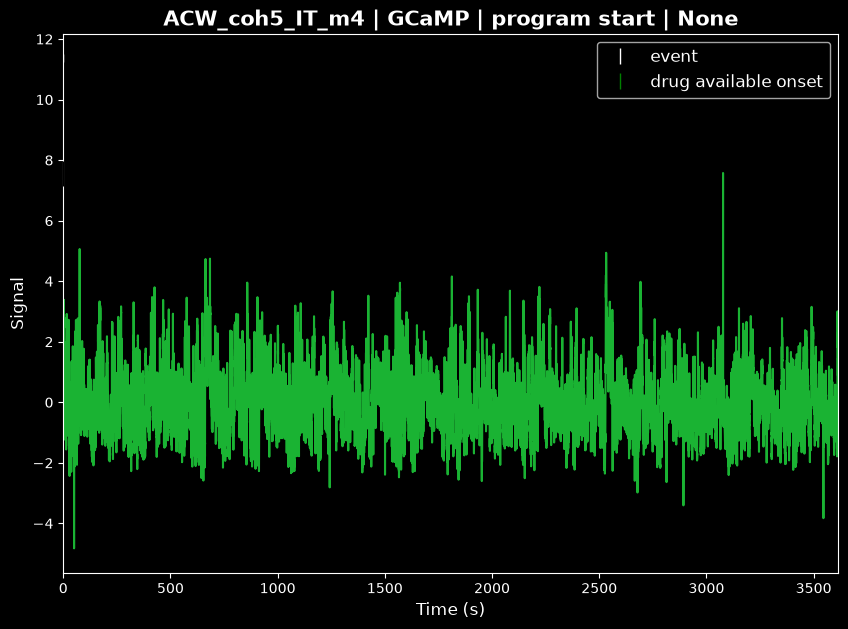

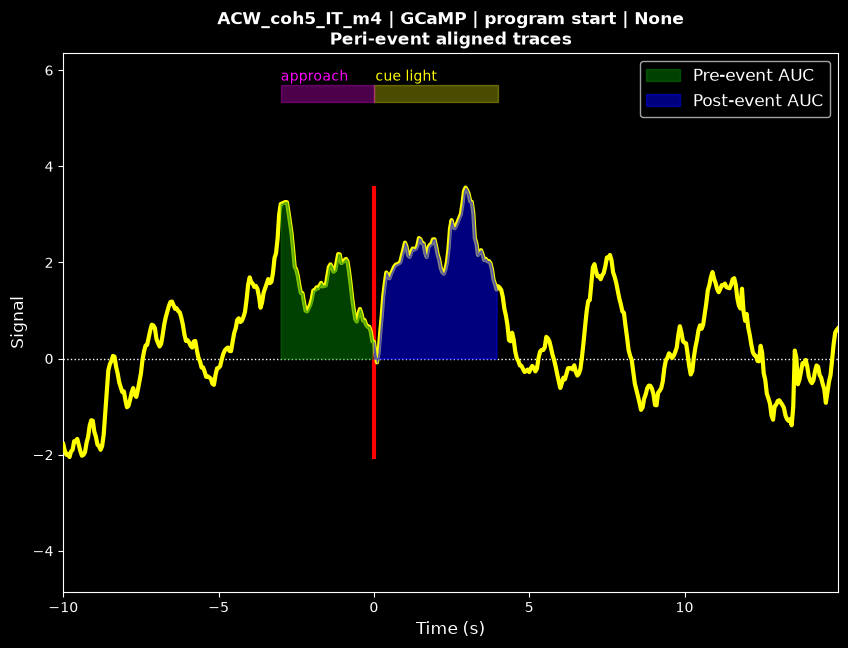

In [10]:
# 013126 update, loop through perievent analysis for channels and events

from fp_func_acw import epoc_streams



# ----------------------------
# Define data streams
# ----------------------------
data_streams = {
    "GCaMP": {
        "name": "GCaMP 465nm motion correction, exponential fit, airPLS, z-scored",
        "data": streams_preproc["GCaMP 465nm motion correction, exponential fit, airPLS, z-scored"]
    },
    "isosbestic": {
        "name": "isosbestic 405nm exponential fit, airPLS, z-scored",
        "data": streams_preproc["isosbestic 405nm exponential fit, airPLS, z-scored"]
    }
}

# ----------------------------
# Event lists by segment mode
# ----------------------------
if segment_mode == "during":
    event_list = ["drug infusion", "active lever", "inactive lever"]
elif segment_mode == None:
    event_list = ["program start", "missed infusion", "active lever", "inactive lever"]  # missed or drug infusion depending on training / PR versus extinction / CR
elif segment_mode in ("before", "after"):
    event_list = ["active lever", "inactive lever"]
elif segment_mode == "transitions":
    event_list = ["drug available", "available_unavailable"]
else:
    raise ValueError(f"Unknown segment_mode: {segment_mode}")

if noncont:
    event_list = ["program start", "cue light", "houselight"]
    
# ----------------------------
# Analysis parameters
# ----------------------------
trange = [-10, 25]   # the format here is [x, y], range begins x seconds before event, and the total duration is y seconds
baseline_trange = [-10, -3]   # this range will depend on the type of event being examined
tzoom = [0, ts[-1]]

cue_duration = 4.0
subset = None # e.g. 5 for first 5 events, (5, 10) for a range, "last5" for final 5 events

approach_window = (-3, 0)
auc_pre_window = (-3, 0)
cue_window = (0, 4)
auc_post_window = (0, 4)

# ----------------------------
# Storage container
# ----------------------------
perievent_results = defaultdict(dict)

# ============================
# MAIN LOOP

# in this loop, the perievent data is collected in a nested dictionary
# the dictionary contains each data stream (GCaMP, isosbestic), then each event type for each stream (infusion, active lever, etc.)
# the first layer (data_key) is the default dict that is automatically created, then populated by dictionaries for each event

# ============================

for data_key, data_info in data_streams.items():
    print(f"\n🧪 Running perievent analysis for data type: {data_key}")
    stream = data_info["data"]

    event_counts = {
        event: (epoc_ts_and_indices["event"] == event).sum()
        for event in event_list
    }
    max_n_events = max(event_counts.values()) if event_counts else 0
    

    for event in event_list:
        print(f"  ▶ Event: {event} ({event_counts[event]} events)")

        label = f"{rat} | {data_key} | {event} | {segment_mode}"

        outputs = epoc_streams(
            epoc_ts_and_indices,
            trange,
            stream,
            new_fs,
            ts,
            event,
            tzoom,
            cue_duration,
            subset=subset,
            cue_window=cue_window,
            auc_pre_window=auc_pre_window,
            auc_post_window=auc_post_window,
            approach_window=approach_window,
            plot_auc_region=True,
            baseline_trange=baseline_trange,
            subset_plots=None,
            pre_buffer_sec=pre_buffer_sec,
            label=label,
        )

        (
            epocs,
            epocs_baselined,
            epocs_mean_std_sem,
            mean_epoc_stream,
            std_epoc_stream,
            sem_epoc_stream,
            fig_5,
            fig_15,
            (cue_mean, cue_sem),
            (auc_pre_mean, auc_pre_sem),
            (auc_post_mean, auc_post_sem),
            (approach_mean, approach_sem),
            subset_figs, 
        ) = outputs

        label_base = f"{rat} | {data_key} | {event}"
        epocs.columns.name = f"{label_base} streams"
        epocs_mean_std_sem.columns.name = f"{label_base} mean, std, sem"

        # ----------------------------
        # Metadata dictionary
        # ----------------------------
        event_parameters = {
            "rat": rat,
            "data type": data_key,
            "preprocessed data stream": data_info["name"],
            "event type examined": event,
            "event count": epocs.shape[1],
            "trange": trange,
            "baseline_trange": baseline_trange,
            "subset": subset,

            "approach window": str(approach_window),
            "mean approach response": f"{approach_mean:.3f}",
            "SEM approach response": f"{approach_sem:.3f}",

            "cue window": str(cue_window),
            "mean cue response": f"{cue_mean:.3f}",
            "SEM cue response": f"{cue_sem:.3f}",

            "pre-event AUC window": str(auc_pre_window),
            "mean pre-event AUC": f"{auc_pre_mean:.3f}",
            "SEM pre-event AUC": f"{auc_pre_sem:.3f}",

            "post-event AUC window": str(auc_post_window),
            "mean post-event AUC": f"{auc_post_mean:.3f}",
            "SEM post-event AUC": f"{auc_post_sem:.3f}"
        }

        events_info = (
            pd.DataFrame.from_dict(event_parameters, orient="index")
            .reset_index()
        )
        events_info.columns = ["perievent analysis", label_base]
        events_info = events_info.astype(str)

        perievent_results[data_key][event] = {
            "epocs": epocs,
            "epocs_baselined": epocs_baselined,
            "epocs_mean_std_sem": epocs_mean_std_sem,
            "mean_trace": mean_epoc_stream,
            "std_trace": std_epoc_stream,
            "sem_trace": sem_epoc_stream,
            "events_info": events_info,
            "fig_5": fig_5,
            "fig_15": fig_15,
            "subset_figs": subset_figs,
            "event_parameters": event_parameters,
            "n_events": event_counts[event]
        }

    
# ============================
# DONE
# ============================
print("\n✅ Perievent analysis complete.")

def print_structure_with_types(d, indent=0):
    for key, val in d.items():
        prefix = "  " * indent
        if isinstance(val, dict):
            print(f"{prefix}- {key}/")
            print_structure_with_types(val, indent + 1)
        else:
            print(f"{prefix}- {key}: {type(val).__name__}")

print_structure_with_types(perievent_results)

if segment_mode == 'during':

    epocs_missed_gcamp = perievent_results["GCaMP"]["drug infusion"]["epocs"]
    display(epocs_missed_gcamp)

    events_info = perievent_results["GCaMP"]["drug infusion"]["events_info"]
    display(events_info)
    
    
'''
if segment_mode == 'transitions':

    epocs_missed_gcamp = perievent_results["GCaMP"]["drug infusion"]["epocs"]
    display(epocs_missed_gcamp)

    events_info = perievent_results["GCaMP"]["drug infusion"]["events_info"]
    display(events_info)

'''


# save the pre-processed streams and peri-event data as feather files


In [28]:
# update save code for perievent analysis update 02.01.26 for perievent loop

'''
feather_folder/
│
├─ {session_id}_{rat}_preproc_info.feather
├─ {session_id}_{rat}_preproc_info.txt
│
├─ Peak Detection (if segment_mode != 'transitions')
│   ├─ {base_path}_peaks_info.feather          ← peak_df
│   ├─ {base_path}_peak_amps.feather          ← peak amplitudes
│   ├─ {base_path}_peak_aucs.feather          ← peak AUCs
│   ├─ {base_path}_peak_df.feather            ← raw_peak_df
│   ├─ {base_path}_baselined_peak_df.feather ← baselined_peak_df
│   └─ {base_path}_peaks_info.txt             ← peak_df text version
│
├─ Perievent Results
│   ├─ {session_id}_{rat}_{data_key}_{event_name}_epocs.feather
│   ├─ {session_id}_{rat}_{data_key}_{event_name}_epocs_baselined.feather
│   ├─ {session_id}_{rat}_{data_key}_{event_name}_epocs_mean_std_sem.feather
│   ├─ {session_id}_{rat}_{data_key}_{event_name}_events_info.feather
│   ├─ {session_id}_{rat}_{data_key}_{event_name}_events_info.txt
│   ├─ {session_id}_{rat}_{data_key}_{event_name}_fig_5.png
│   ├─ {session_id}_{rat}_{data_key}_{event_name}_fig_15.png
│   ├─ {session_id}_{rat}_{data_key}_{event_name}_subset_1.png
│   ├─ {session_id}_{rat}_{data_key}_{event_name}_subset_2.png
│   └─ {session_id}_{rat}_{data_key}_{event_name}_event_parameters.feather
│
└─ Other preprocessed streams
    └─ {base_path}_streams_preproc.feather

'''


#################################################################################################################################




# Save directory and info
feather_folder = r"D:\ACW\photometry\cohort_5_101325\extracted\CR\processed_CR_GCaMP8s_highrisk"




#################################################################################################################################

# -----------------------------
os.makedirs(feather_folder, exist_ok=True)
print(f"\n📁 Files will be saved in:\n   {feather_folder}\n")

# -----------------------------
# --- Helper functions ---
# -----------------------------
def clean_filename_component(s):
    """Clean strings for use in filenames."""
    return re.sub(r'[<>:"/\\|?*]', '', str(s).replace(' ', '_'))

def safe_feather_save(df, filepath):
    """Save a DataFrame as Feather with overwrite protection."""
    if os.path.exists(filepath):
        print(f"\n⚠️  File already exists at:\n   {filepath}\n🛑 Skipping save.\n")
        return
    if df is None:
        print(f"\n⚠️  Warning: No DataFrame provided for:\n   {filepath}\n🛑 Skipping save.\n")
        return
    if df.empty:
        print(f"\n⚠️  Warning: Empty DataFrame at:\n   {filepath}\n🛑 Skipping save.\n")
        return

    df = df.reset_index(drop=True)
    df.columns = [str(col) for col in df.columns]
    df.to_feather(filepath)
    print(f"💾 Saved Feather file:\n   {filepath}")

# -----------------------------
# --- Base filename ---
# -----------------------------
if segment_mode == 'during':
    avail_tag = 'Avail_'
elif segment_mode == 'before':
    avail_tag = 'Unavail_late_'
elif segment_mode == 'after':
    avail_tag = 'Unavail_early_'
elif segment_mode == 'transitions':
    avail_tag = 'transitions_'
elif segment_mode is None:
    avail_tag = ''
else:
    raise ValueError(f"❌ Unknown segment_mode: {segment_mode}")

session_clean = clean_filename_component(session_id)
rat_clean = clean_filename_component(rat)
base_path = os.path.join(feather_folder, f"{session_clean}_{avail_tag}{rat_clean}")
print(f"📦 Base path for this session: {base_path}\n")

# -----------------------------
# --- Preprocessing info ---
# -----------------------------
if segment_mode != 'transitions':
    preproc_info = {
        "session ID": session_id,
        "rats and box assignments in this group": json.dumps(box_to_rat, indent=4),
        "rat analyzed": rat,
        "new fs after downsample": new_fs,
        "lowpass filter (Hz)": filt,
        "light artifacts corrected for:": correct_stream,
        "lambda value used for airPLS correction": lambda_,
        "code used for dropsec during stream trimming": dropsec_code,
        "startcode (for selecting time segment)": startcode,
        "time interval dropped from beginning of stream (sec)": (
            dropsec_all[startcode] if isinstance(dropsec_all, (list, np.ndarray)) and len(dropsec_all) > startcode
            else "N/A"
        ),
        "duration of examined stream data (min)": keepmin_streams,
    }

    # Feather
    preproc_df_path = base_path + "_preproc_info.feather"
    preproc_info_df = pd.DataFrame.from_dict(preproc_info, orient='index').reset_index()
    preproc_info_df.columns = ['preprocessing info', rat_clean]
    preproc_info_df = preproc_info_df.astype(str)
    safe_feather_save(preproc_info_df, preproc_df_path)

    # TXT
    preproc_txt_path = base_path + "_preproc_info.txt"
    if not os.path.exists(preproc_txt_path):
        with open(preproc_txt_path, 'w') as f:
            for key, value in preproc_info.items():
                f.write(f"{key:<45}: {value}\n")
        print(f"📝 Saved preprocessing info (text): {preproc_txt_path}")

# -----------------------------
# --- Peak detection ---
# -----------------------------
if segment_mode != 'transitions':
    peak_saves = {
        'peak_df': '_peaks_info',
        'peak_amps': '_peak_amps',
        'peak_aucs': '_peak_aucs',
        'raw_peak_df': '_peak_df',
        'baselined_peak_df': '_baselined_peak_df'
    }

    for var_name, suffix in peak_saves.items():
        if var_name in locals() or var_name in globals():
            data = locals().get(var_name, globals().get(var_name))
            if data is not None:
                safe_feather_save(data, base_path + suffix + ".feather")
                if var_name == 'peak_df':
                    txt_path = base_path + suffix + ".txt"
                    if not os.path.exists(txt_path):
                        with open(txt_path, 'w') as f:
                            f.write(data.to_string(index=False))
                        print(f"📝 Saved peak info (text): {txt_path}")
        else:
            print(f"⚠️ Warning: '{var_name}' not defined. Skipping save.")

# -----------------------------
# --- Perievent results ---
# -----------------------------
for data_key, events_dict in perievent_results.items():
    data_safe = clean_filename_component(data_key)
    
    for event_name, result_dict in events_dict.items():
        event_safe = clean_filename_component(event_name)

        # Save DataFrames
        for df_key, suffix in [
            ("epocs", "_epocs.feather"),
            ("epocs_baselined", "_epocs_baselined.feather"),
            ("epocs_mean_std_sem", "_epocs_mean_std_sem.feather"),
            ("events_info", "_events_info.feather")
        ]:
            if df_key in result_dict:
                safe_feather_save(result_dict[df_key],
                                  os.path.join(feather_folder, f"{session_clean}_{avail_tag}{rat_clean}_{data_safe}_{event_safe}{suffix}"))

        # Save events_info TXT
        if "events_info" in result_dict:
            txt_path = os.path.join(feather_folder, f"{session_clean}_{avail_tag}{rat_clean}_{data_safe}_{event_safe}_events_info.txt")
            if not os.path.exists(txt_path):
                with open(txt_path, "w") as f:
                    f.write(result_dict["events_info"].to_string(index=False))
                print(f"📝 Saved events info (text): {txt_path}")

        
        # Save event_parameters
        if "event_parameters" in result_dict:
            ep_df = pd.DataFrame.from_dict(result_dict["event_parameters"], orient="index").reset_index()
            ep_df.columns = ["parameter", "value"]
            ep_df = ep_df.astype(str)  # <-- convert all to string
            safe_feather_save(
                ep_df,
                os.path.join(
                    feather_folder,
                    f"{session_clean}_{avail_tag}{rat_clean}_{data_safe}_{event_safe}_event_parameters.feather"
                )
            )


        '''
        # Save figures
        for fig_key in ["fig_5", "fig_15"]:
            if fig_key in result_dict and result_dict[fig_key] is not None:
                fig = result_dict[fig_key]
                fig_path = os.path.join(feather_folder, f"{session_clean}_{avail_tag}{rat_clean}_{data_safe}_{event_safe}_{fig_key}.png")
                fig.savefig(fig_path, dpi=150)
                print(f"🖼️ Saved figure: {fig_path}")
                plt.close(fig)
        
        # Save subset figures
        if "subset_figs" in result_dict and result_dict["subset_figs"] is not None:
            for i, fig in enumerate(result_dict["subset_figs"]):
                fig_path = os.path.join(feather_folder,
                                        f"{session_clean}_{avail_tag}{rat_clean}_{data_safe}_{event_safe}_subset_{i+1}.png")
                fig.savefig(fig_path, dpi=150)
                print(f"🖼️ Saved subset figure: {fig_path}")
                plt.close(fig)
        '''
        
        


📁 Files will be saved in:
   D:\ACW\photometry\cohort_5_101325\extracted\CR\processed_CR_GCaMP8s_highrisk

📦 Base path for this session: D:\ACW\photometry\cohort_5_101325\extracted\CR\processed_CR_GCaMP8s_highrisk\ACW_coh5a_111325_0001_ACW_coh5_IT_f1


⚠️  File already exists at:
   D:\ACW\photometry\cohort_5_101325\extracted\CR\processed_CR_GCaMP8s_highrisk\ACW_coh5a_111325_0001_ACW_coh5_IT_f1_preproc_info.feather
🛑 Skipping save.


⚠️  File already exists at:
   D:\ACW\photometry\cohort_5_101325\extracted\CR\processed_CR_GCaMP8s_highrisk\ACW_coh5a_111325_0001_ACW_coh5_IT_f1_peaks_info.feather
🛑 Skipping save.


⚠️  File already exists at:
   D:\ACW\photometry\cohort_5_101325\extracted\CR\processed_CR_GCaMP8s_highrisk\ACW_coh5a_111325_0001_ACW_coh5_IT_f1_peak_amps.feather
🛑 Skipping save.


⚠️  File already exists at:
   D:\ACW\photometry\cohort_5_101325\extracted\CR\processed_CR_GCaMP8s_highrisk\ACW_coh5a_111325_0001_ACW_coh5_IT_f1_peak_aucs.feather
🛑 Skipping save.


⚠️  File alrea

# load and view saved epoc streams

In [ ]:
feather_folder =  r'D:\ACW\photometry\cohort_5_101325\extracted\training\processed_training_late_GcaMP6s_highrisk'

file_pattern='*ACW_coh5_IT_f2_drug_infusion_*GCaMP_465_epocs.feather'     # each file individually
#file_pattern='*ACW_coh2a_IT_m1_baselined_peak_df.feather'     # each file individually


#file_pattern = 'multiday_processed_extinction_ACW_coh2a_IT_m1_active_GCaMP_465_epocs.feather'   # the multiday combined file

processed_phase = os.path.basename(feather_folder)

# Load, concatenate, compute stats, and plot

from fp_func_acw import load_compute_plot

file_dfs, file_stats, file_figs = load_compute_plot(feather_folder, file_pattern, new_fs, ts, trange,  baseline_trange = [-10,-5], cue_window = (0,4), approach_window=(-3,0))




## concatenate perievent dataframes from multiple recording segments in the same day (e.g. available periods during IntA SA) or from multiple recording segments across days (e.g. both CR days)

### save the within-day or multi-day combined epoc dataframes and stats


In [ ]:
########################################################################################################################
# updated 01.22.26 to handle multiple animals in coh5 analysis
# new streamlined function to parallel peak processing
import os
import glob
import re
from pathlib import Path
import numpy as np
import pandas as pd
from fp_func_acw_051926 import run_perievent_pipeline_with_partials, save_combined_perievent_results

# -----------------------------
# INPUT CONFIGURATION
# -----------------------------
# Single-day example
feather_folder = r"D:\ACW\photometry\cohort_5_101325\extracted\training\processed_training_early_GCaMP6s_highrisk"
file_pattern = '*ACW_coh5_IT_*_drug_infusion_*GCaMP_465_epocs.feather'

# Multi-day example (uncomment if needed)

'''
feather_folder = [
     r"D:\ACW\photometry\cohort_2_110824\cohort2_extracted\processed_extinction_1",
     r"D:\ACW\photometry\cohort_2_110824\cohort2_extracted\processed_extinction_2"
]
multiday_feather_folder = r"D:\ACW\photometry\cohort_2_110824\cohort2_extracted\multiday_processed_extinction"
file_pattern = '*ACW_coh2a_IT_m2_active_GCaMP_465_epocs.feather'
'''

# -----------------------------
# DETECT MULTIDAY
# -----------------------------
multiday = isinstance(feather_folder, list)

# Gather files
matched_files = []
if multiday:
    for folder in feather_folder:
        matched_files.extend(glob.glob(os.path.join(folder, file_pattern)))
    processed_phase = os.path.basename(multiday_feather_folder)
else:
    matched_files = glob.glob(os.path.join(feather_folder, file_pattern))
    processed_phase = os.path.basename(feather_folder)

# -----------------------------
# TIME AND WINDOW PARAMETERS
# -----------------------------
compute_kwargs = {
    "baseline_trange": (-10, -5),
    "approach_window": (-3, 0),
    "cue_window": (0, 4),
    "auc_pre_window": (-3, 0),
    "auc_post_window": (0, 4),
    "new_fs": 20.0,
    "trange": [-10, 25],
}
compute_kwargs["ts"] = np.arange(compute_kwargs["trange"][0],
                                 compute_kwargs["trange"][1],
                                 1/compute_kwargs["new_fs"])

# -----------------------------
# FILENAME PARSING
# -----------------------------
def parse_rat_event(filename):
    fname = Path(filename).stem
    rat_match = re.search(r'ACW_coh5_IT_[fm]\d+', fname)
    rat = rat_match.group(0) if rat_match else 'unknown_rat'
    if rat_match:
        start_idx = rat_match.end() + 1
        end_idx = fname.rfind('_GCaMP')
        eventname = fname[start_idx:end_idx]
    else:
        eventname = 'unknown_event'
    eventname = eventname.strip('_')
    eventname = re.sub(r'_combined$', '', eventname)
    return rat, eventname

# Generate eventname and rat_str
all_events = sorted({parse_rat_event(f)[1] for f in matched_files})
eventname = "-".join(all_events)
eventname = re.sub(r'[<>:"/\\|?*]', '_', eventname)

all_rats = sorted({parse_rat_event(f)[0] for f in matched_files})
rat_str = "-".join(all_rats)
rat_str = re.sub(r'[<>:"/\\|?*]', '_', rat_str)

# -----------------------------
# RUN PIPELINE
# -----------------------------
pipeline_results = run_perievent_pipeline_with_partials(
    matched_files,
    save_dir=multiday_feather_folder if multiday else feather_folder,
    processed_phase=processed_phase,
    eventname=eventname,
    compute_kwargs=compute_kwargs,
    overwrite=False
)

combined_epocs = pipeline_results["combined_epocs"]
combined_stats = pipeline_results["combined_stats"]
fig_all = pipeline_results["fig_all"]

# Extract summary stats for combined_event_dict
# The pipeline must be updated to return these; assume it now returns:
# 'cue_stats', 'approach_stats', 'auc_pre_stats', 'auc_post_stats'
cue_mean, cue_sem = pipeline_results.get('cue_stats', (np.nan, np.nan))
approach_mean, approach_sem = pipeline_results.get('approach_stats', (np.nan, np.nan))
auc_pre_mean, auc_pre_sem = pipeline_results.get('auc_pre_stats', (np.nan, np.nan))
auc_post_mean, auc_post_sem = pipeline_results.get('auc_post_stats', (np.nan, np.nan))

# -----------------------------
# COMBINE SUMMARY INFO
# -----------------------------
combined_event_dict = {
    "eventname": eventname,
    "rats included": rat_str,
    "event count": combined_epocs.shape[1],
    "approach window (s)": str(compute_kwargs["approach_window"]),
    "mean approach response": f"{approach_mean:.3f}",
    "SEM approach response": f"{approach_sem:.3f}",
    "cue window (s)": str(compute_kwargs["cue_window"]),
    "mean cue response": f"{cue_mean:.3f}",
    "SEM cue response": f"{cue_sem:.3f}",
    "pre-event AUC window (s)": str(compute_kwargs["auc_pre_window"]),
    "mean pre-event AUC": f"{auc_pre_mean:.3f}",
    "SEM pre-event AUC": f"{auc_pre_sem:.3f}",
    "post-event AUC window (s)": str(compute_kwargs["auc_post_window"]),
    "mean post-event AUC": f"{auc_post_mean:.3f}",
    "SEM post-event AUC": f"{auc_post_sem:.3f}",
}

# Convert to DataFrame
combined_events_info = pd.DataFrame.from_dict(combined_event_dict, orient='index').reset_index()
combined_events_info.columns = ['combined perievent analysis', '']

# Add matched files for reference
matched_file_rows = pd.DataFrame({
    'combined perievent analysis': ['matched file'] * len(matched_files),
    '': [Path(f).name for f in matched_files]
})

combined_events_info = pd.concat([matched_file_rows, combined_events_info], ignore_index=True).astype(str)

# Display results
display(combined_events_info)
display(combined_epocs)

# -----------------------------
# SAVE RESULTS
# -----------------------------
save_combined_perievent_results(
    multiday_feather_folder if multiday else feather_folder,
    processed_phase,
    rat_str,
    eventname,
    combined_epocs,
    combined_stats,
    combined_events_info
)


# combined analysis for peak detection

In [ ]:
# updated 01.22.26 to handle multiple rats
from fp_func_acw import load_combine_and_save_peak_data_multi
from pathlib import Path
import re
import pandas as pd

# Folder containing all peak files
folder = r"D:\ACW\photometry\cohort_5_101325\extracted\training\processed_training_early_GCaMP6s_highrisk"

# Optional: filter to a specific rat, leave as None to include all
target_rat = None

# Generate a filename prefix for saving
folder_prefix = Path(folder).name
filename_prefix = f"{folder_prefix}_"

# Build glob patterns (matches all rats/events in folder)
amp_pattern = "*_peak_amps.feather"
auc_pattern = "*_peak_aucs.feather"
info_pattern = "*_peaks_info.feather"
baselined_peak_pattern = "*_baselined_peak_df.feather"
preproc_info_txt_pattern = "*_preproc_info.txt"

# Call the multi-rat function
per_rat_outputs, combined_outputs_all = load_combine_and_save_peak_data_multi(
    folder,
    amp_pattern,
    auc_pattern,
    info_pattern,
    filename_prefix=filename_prefix,
    preproc_info_txt_pattern=preproc_info_txt_pattern,
    baselined_peak_pattern=baselined_peak_pattern
)

# Unpack the across-animal combined outputs
summary_all_recalc, combined_amps_all, combined_aucs_all, combined_baselined_all, fig_all = combined_outputs_all

# If you want to only display a specific rat:
if target_rat is not None:
    if target_rat in per_rat_outputs:
        summary_df, combined_amps_df, combined_aucs_df, combined_baselined_df = per_rat_outputs[target_rat][:4]
        display(summary_df)
        display(combined_baselined_df)
    else:
        print(f"⚠️ No data found for rat: {target_rat}")
else:
    # Multiple rats: display the combined outputs across all animals
    display(summary_all_recalc)
    display(combined_baselined_all)

print(combined_baselined_all.columns)